# EV Forecasting and Envelope Construction

This notebook builds 15-minute forecasts of uncontrolled EV charging for 2025 based on 2024 data, and derives:

- `ev_forecast_2025[t]`: 15-min uncontrolled EV forecast (kWh per interval).
- `ev_daily_energy_forecast_2025[date]`: daily EV energy forecast (kWh).
- `ev_envelope_forecast_2025[t]`: EV charging power envelope (kW) used as a constraint in MPC.

It also evaluates several forecasting strategies on 2024 data:

- **Strategy A**: Same time last week

## Part 1 – Data input and preparation

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

DATA_DIR = Path("../data")
TRAIN_PATH_2024 = DATA_DIR / "plant1_2024_training.csv"
DATA_2025_PATH = DATA_DIR / "plant1.csv"

TRAIN_PATH_2024, DATA_2025_PATH

(WindowsPath('../data/plant1_2024_training.csv'),
 WindowsPath('../data/plant1.csv'))

In [2]:
# Load 2024 training data (EV only) and 2025 full data


def load_ev_data():
    """Load 2024 EV training data and 2025 full data with consistent timestamp parsing.

    We follow the approach from 00_input_data_testing.ipynb:
    - Parse timestamps as UTC.
    - Convert to Europe/Brussels.
    - Drop timezone info (naive local time).
    This avoids DST / offset issues that caused problems before.
    """
    df_2024 = pd.read_csv(TRAIN_PATH_2024)
    df_2025 = pd.read_csv(DATA_2025_PATH)

    # Parse timestamps via UTC, then convert to Europe/Brussels and drop tzinfo
    for df in (df_2024, df_2025):
        ts_utc = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
        df["timestamp"] = ts_utc.dt.tz_convert("Europe/Brussels").dt.tz_localize(None)
        df.sort_values("timestamp", inplace=True)

    # Ensure EV column is numeric and non-null
    df_2024["ev"] = pd.to_numeric(df_2024["ev"], errors="coerce").fillna(0.0)
    if "ev" in df_2025.columns:
        df_2025["ev"] = pd.to_numeric(df_2025["ev"], errors="coerce").fillna(0.0)

    # Ensure we only keep the EV column from 2024 training file
    df_2024 = df_2024[["timestamp", "ev"]].copy()

    return df_2024.reset_index(drop=True), df_2025.reset_index(drop=True)


df_2024, df_2025 = load_ev_data()
df_2024.head(), df_2025.head()

(            timestamp   ev
 0 2024-01-01 00:00:00  0.0
 1 2024-01-01 00:15:00  0.0
 2 2024-01-01 00:30:00  0.0
 3 2024-01-01 00:45:00  0.0
 4 2024-01-01 01:00:00  0.0,
             timestamp  grid_consumption  price  pv_production  grid_injection  \
 0 2025-01-01 00:00:00           160.125  10.62            0.0             0.0   
 1 2025-01-01 00:15:00           161.875  10.62            0.0             0.0   
 2 2025-01-01 00:30:00           163.625  10.62            0.0             0.0   
 3 2025-01-01 00:45:00           154.000  10.62            0.0             0.0   
 4 2025-01-01 01:00:00           154.000  10.27            0.0             0.0   
 
    total_consumption   ev  inflex_load  grid_consumption_excl_ev  \
 0            160.125  0.0      160.125                   160.125   
 1            161.875  0.0      161.875                   161.875   
 2            163.625  0.0      163.625                   163.625   
 3            154.000  0.0      154.000                   154

In [3]:
# Add calendar features and detect EV go-live date in 2024

for df in (df_2024, df_2025):
    df["date"] = df["timestamp"].dt.date
    df["day_of_week"] = df["timestamp"].dt.dayofweek  # 0=Mon
    df["time_of_day"] = df["timestamp"].dt.hour + df["timestamp"].dt.minute / 60.0
    df["month"] = df["timestamp"].dt.month
    df["day_of_year"] = df["timestamp"].dt.dayofyear

# Detect EV go-live date: first day with non-trivial EV usage
EV_DAILY_THRESHOLD_KWH = 1.0

daily_ev_2024 = (
    df_2024.groupby("date")["ev"].sum().reset_index(name="ev_daily_kwh")
)

nonzero_days = daily_ev_2024[daily_ev_2024["ev_daily_kwh"] > EV_DAILY_THRESHOLD_KWH]
if len(nonzero_days) == 0:
    raise RuntimeError("No non-zero EV days found in 2024 training data.")

ev_start_date_2024 = nonzero_days["date"].min()

print(f"Detected EV go-live date in 2024: {ev_start_date_2024}")

daily_ev_2024.tail()

Detected EV go-live date in 2024: 2024-05-07


,date,ev_daily_kwh
361,2024-12-27,442.250
362,2024-12-28,0.000
363,2024-12-29,0.000
364,2024-12-30,746.875
365,2024-12-31,276.125


### Yearly EV energy overview

To understand the overall EV charging behavior before building forecasts, we first compare **daily EV energy** in 2024 and 2025 on a single plot.

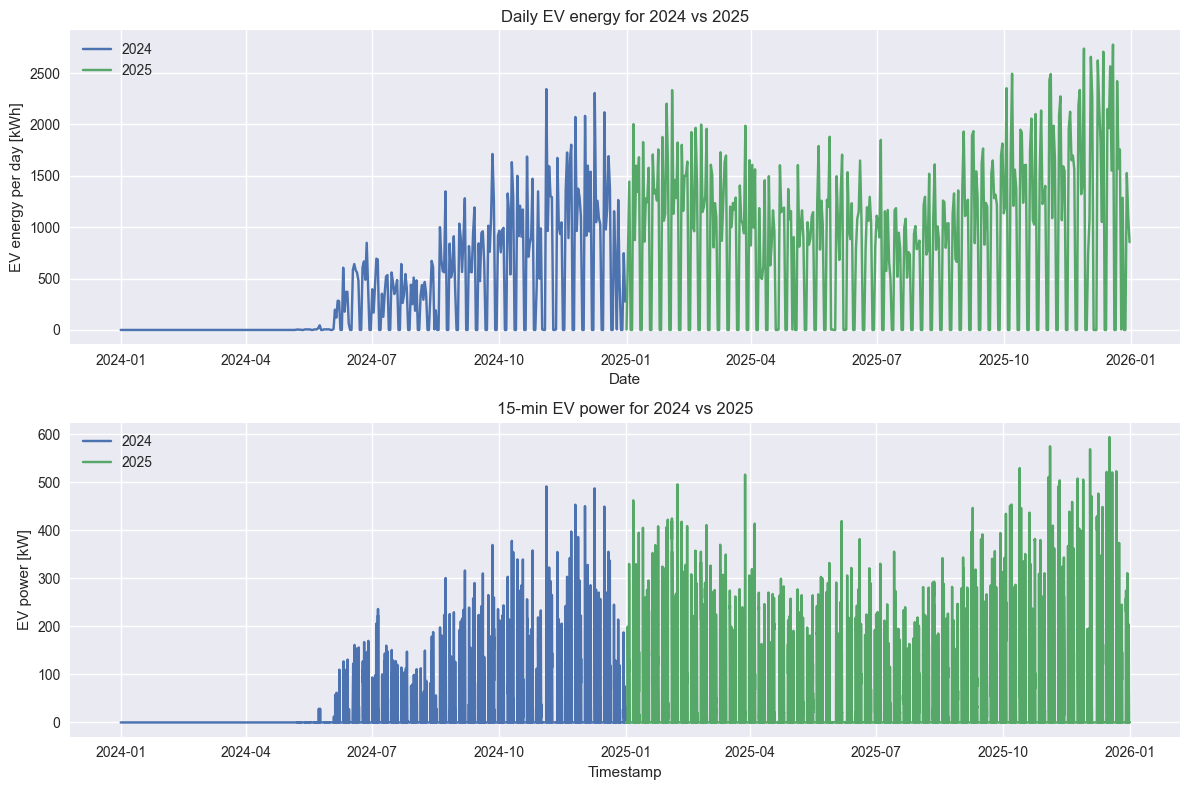

In [4]:
# Daily EV energy and power for 2024 vs 2025

# Aggregate daily EV energy (kWh) for 2025
daily_ev_2025 = (
    df_2025.groupby("date")["ev"].sum().reset_index(name="ev_daily_kwh")
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Top: daily EV energy
ax1.plot(daily_ev_2024["date"], daily_ev_2024["ev_daily_kwh"], label="2024")
ax1.plot(daily_ev_2025["date"], daily_ev_2025["ev_daily_kwh"], label="2025")
ax1.set_title("Daily EV energy for 2024 vs 2025")
ax1.set_xlabel("Date")
ax1.set_ylabel("EV energy per day [kWh]")
ax1.legend()
ax1.grid(True)

# Bottom: 15-min EV power (kW)
# Original data is kWh per 15 minutes, so multiply by 4 to get kW
ax2.plot(df_2024["timestamp"], df_2024["ev"] * 4.0, label="2024")
ax2.plot(df_2025["timestamp"], df_2025["ev"] * 4.0, label="2025")
ax2.set_title("15-min EV power for 2024 vs 2025")
ax2.set_xlabel("Timestamp")
ax2.set_ylabel("EV power [kW]")
ax2.legend()
ax2.grid(True)

plt.tight_layout()

### Weekly and daily EV power views

Below we inspect **EV charging power (kW)** for a selectable ISO week (year + week number), showing both the full week and one representative day.

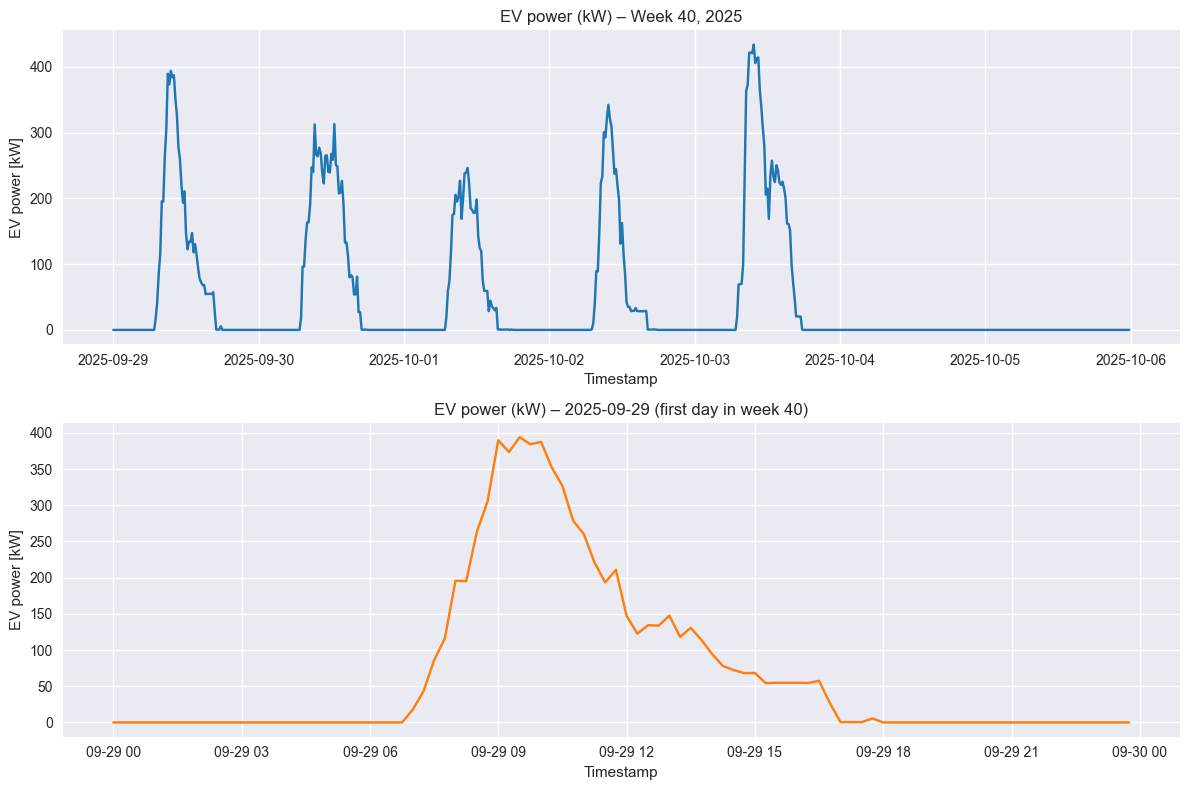

In [5]:
# Weekly and daily EV power (kW) for a selectable year/week

# Parameters: adjust these to inspect another period
year_for_plots = 2025  # 2024 or 2025
week_number = 40       # ISO week number (1–53)

# Choose source dataframe based on year
if year_for_plots == 2024:
    df_src = df_2024.copy()
elif year_for_plots == 2025:
    df_src = df_2025.copy()
else:
    raise ValueError("year_for_plots must be 2024 or 2025.")

# Compute ISO calendar fields
iso = df_src["timestamp"].dt.isocalendar()
mask_week = (iso["year"] == year_for_plots) & (iso["week"] == week_number)

df_week = df_src.loc[mask_week].copy()

if df_week.empty:
    raise ValueError(f"No data found for year={year_for_plots}, week={week_number}.")

# Convert from kWh/15min to kW
df_week["power_kw"] = df_week["ev"] * 4.0

df_week["date"] = df_week["timestamp"].dt.date

# Pick a representative day within this week (first date in the week)
selected_date = df_week["date"].min()
df_day = df_week[df_week["date"] == selected_date].copy()

fig, (ax_week, ax_day) = plt.subplots(2, 1, figsize=(12, 8), sharey=False)

# Weekly view
ax_week.plot(df_week["timestamp"], df_week["power_kw"], color="tab:blue")
ax_week.set_title(f"EV power (kW) – Week {week_number}, {year_for_plots}")
ax_week.set_xlabel("Timestamp")
ax_week.set_ylabel("EV power [kW]")
ax_week.grid(True)

# Daily view (first day in that ISO week)
ax_day.plot(df_day["timestamp"], df_day["power_kw"], color="tab:orange")
ax_day.set_title(f"EV power (kW) – {selected_date} (first day in week {week_number})")
ax_day.set_xlabel("Timestamp")
ax_day.set_ylabel("EV power [kW]")
ax_day.grid(True)

plt.tight_layout()

## Part 2 – Forecasting strategies

This section defines and applies forecasting strategies for uncontrolled EV charging:

- **Strategy A**: Same time last week (benchmark)
- **Strategy B**: Average of last K weeks (same time)
- **Strategy C**: Chronos2 foundation model (rolling day-ahead)

In [6]:
# Exclude last N weeks of the year from forecast source (holiday period). Set to 0 to disable.
EXCLUDE_LAST_WEEKS_OF_YEAR = 2  # e.g. 2 = last 2 weeks (Dec 18–31)

def in_excluded_period(ts):
    """True if timestamp falls in the last EXCLUDE_LAST_WEEKS_OF_YEAR weeks of the year."""
    if EXCLUDE_LAST_WEEKS_OF_YEAR <= 0:
        return np.zeros(len(ts), dtype=bool) if hasattr(ts, "__len__") else False
    t = pd.Series(ts) if not isinstance(ts, pd.Series) else ts
    doy = t.dt.dayofyear.values
    days_in_year = 366 if t.dt.is_leap_year.any() else 365
    threshold = days_in_year - 7 * EXCLUDE_LAST_WEEKS_OF_YEAR + 1
    return doy >= threshold

In [7]:
# Strategy A – Same time last week (benchmark) for 2025
# For the first week of 2025 (no "last week" in 2025), use last weeks of 2024.
# If EXCLUDE_LAST_WEEKS_OF_YEAR > 0, skip lags whose source falls in that period; use next non-excluded lag.
# Use timestamp-based lookup (no merge) so DST duplicate timestamps do not multiply rows.

_df_2025 = df_2025.copy().sort_values("timestamp").reset_index(drop=True)

# One row per naive timestamp (avoids duplicate keys when mapping; keep first occurrence)
ev_2024_by_ts = df_2024.drop_duplicates(subset=["timestamp"], keep="first").set_index("timestamp")["ev"]
ev_2025_by_ts = _df_2025.drop_duplicates(subset=["timestamp"], keep="first").set_index("timestamp")["ev"]

LAG_DAYS = [7, 14, 21, 28, 35]
prev_2025_cols = []
prev_2024_cols = []

for L in LAG_DAYS:
    source_ts = _df_2025["timestamp"] - pd.Timedelta(days=L)
    _df_2025[f"prev_2025_L{L}"] = source_ts.map(ev_2025_by_ts)
    _df_2025[f"prev_2024_L{L}"] = source_ts.map(ev_2024_by_ts)
    prev_2025_cols.append(f"prev_2025_L{L}")
    prev_2024_cols.append(f"prev_2024_L{L}")

# For each lag L, source timestamp is t - L days; exclude if in holiday period
ts = _df_2025["timestamp"]
forecast = np.full(len(_df_2025), np.nan)
for i, L in enumerate(LAG_DAYS):
    source_ts = ts - pd.Timedelta(days=L)
    excluded = in_excluded_period(source_ts)
    prev_2025 = _df_2025[prev_2025_cols[i]]
    prev_2024 = _df_2025[prev_2024_cols[i]]
    val = prev_2025.fillna(prev_2024)
    use = ~excluded & val.notna()
    forecast[use] = np.where(np.isnan(forecast[use]), val[use].values, forecast[use])

_df_2025["ev_forecast_2025"] = np.where(np.isnan(forecast), 0.0, forecast)
# Drop temporary lag columns to keep dataframe clean
_df_2025 = _df_2025.drop(columns=[c for c in _df_2025.columns if c.startswith("prev_202") and "L" in c])

# Overwrite df_2025 with the enriched DataFrame (still has a normal RangeIndex)
df_2025 = _df_2025
# --- Daily EV energy forecast (kWh per day) ---
ev_daily_energy_forecast_2025 = (
    df_2025.groupby("date")["ev_forecast_2025"].sum()
)

# --- EV power envelope forecast (kW) derived from the Strategy A forecast ---
# Convert 15-min energy (kWh/interval) to power (kW)
ev_power_forecast_2025 = df_2025["ev_forecast_2025"].values * 4.0

_time_of_day = df_2025["timestamp"].dt.hour + df_2025["timestamp"].dt.minute / 60.0
_dates_2025 = df_2025["date"].values

ev_envelope_forecast_2025_array = np.zeros_like(ev_power_forecast_2025)

_unique_dates_2025 = np.unique(_dates_2025)

for d in _unique_dates_2025:
    mask = _dates_2025 == d
    idx = np.where(mask)[0]
    day_power = ev_power_forecast_2025[idx]
    day_tod = _time_of_day.iloc[idx].values

    # Cumulative maximum up to each time point
    cum_max = np.maximum.accumulate(day_power)

    # Power at 15:30
    before_1530 = day_tod <= 15.5
    if np.any(before_1530):
        last_1530_idx = np.where(before_1530)[0][-1]
        p_max_1530 = cum_max[last_1530_idx]
    else:
        p_max_1530 = cum_max[0] if len(cum_max) > 0 else 0.0

    # Piecewise envelope per day
    for i_local, t_hour in enumerate(day_tod):
        i_global = idx[i_local]
        if t_hour <= 15.5:
            ev_envelope_forecast_2025_array[i_global] = cum_max[i_local]
        elif 15.5 < t_hour < 17.0:
            ev_envelope_forecast_2025_array[i_global] = p_max_1530 * (17.0 - t_hour) / 1.5
        else:
            ev_envelope_forecast_2025_array[i_global] = 0.0

# Attach envelope to df_2025 (kW)
df_2025["ev_envelope_forecast_2025_kw"] = ev_envelope_forecast_2025_array

# Expose the main forecast objects with the names introduced in the notebook header
#  - ev_forecast_2025[t]: 15-min energy forecast (kWh/interval)
#  - ev_envelope_forecast_2025[t]: EV power envelope (kW)
#  - ev_daily_energy_forecast_2025[date]: daily energy forecast (kWh)
ev_forecast_2025 = df_2025.set_index("timestamp")["ev_forecast_2025"]
ev_envelope_forecast_2025 = df_2025.set_index("timestamp")["ev_envelope_forecast_2025_kw"]

### Strategy B – Average of last K weeks (same time)

Strategy B generalizes Strategy A by forecasting each 15‑minute interval as the **average of the same timestamp over the last K weeks**:

- For K=2: average of the last 2 weeks at the same day/time.
- For K=3: average of the last 3 weeks at the same day/time.
- ... up to K=16.

We denote these variants as **B2, B3, ..., B16**; **B1** would coincide with Strategy A and is not recomputed.

In [8]:
# Strategy B – average of last K weeks (same time)
# For each lag week j, value at t-7j days is taken from 2025 if available, else from 2024.
# If EXCLUDE_LAST_WEEKS_OF_YEAR > 0, exclude those j for which t-7j falls in that period from the average.

K_VALUES_B = list(range(1, 17))  # 1..16 (K=1 == Strategy A)

_df_base_2025 = df_2025.copy().sort_values("timestamp").reset_index(drop=True)
ts = _df_base_2025["timestamp"]

# Combined series: 2024 and 2025 ev by timestamp (for looking up t-7j days)
_combined_ev = pd.concat([
    df_2024.set_index("timestamp")["ev"],
    df_2025.set_index("timestamp")["ev"],
])

for k in K_VALUES_B:
    prev_arrays = []
    excluded_mask = []  # shape (n_rows, k): True if that lag's source is in excluded period
    for j in range(1, k + 1):
        source_ts = ts - pd.Timedelta(days=7 * j)
        excluded_mask.append(in_excluded_period(source_ts))
        lagged_j = _combined_ev.copy()
        lagged_j.index = lagged_j.index + pd.Timedelta(days=7 * j)
        lagged_j = lagged_j[~lagged_j.index.duplicated(keep="last")]
        prev_j = _df_base_2025["timestamp"].map(lagged_j).to_numpy()
        prev_arrays.append(prev_j)

    vals = np.stack(prev_arrays, axis=1)  # (n, k)
    excluded = np.stack(excluded_mask, axis=1)  # (n, k)
    # Where excluded, set to nan so they are not included in the mean
    vals_masked = np.where(excluded, np.nan, vals)
    with np.errstate(all="ignore"):
        ev_forecast_k = np.nanmean(vals_masked, axis=1)
    # If all k lags were excluded for a row, fall back to first non-excluded lag (if any)
    all_excluded = np.all(excluded, axis=1)
    if np.any(all_excluded):
        for j in range(k):
            use = all_excluded & ~excluded[:, j] & ~np.isnan(vals[:, j])
            if np.any(use):
                ev_forecast_k[use] = vals[use, j]
                all_excluded = all_excluded & ~use
    ev_forecast_k = np.where(np.isnan(ev_forecast_k), 0.0, ev_forecast_k)

    _df_base_2025[f"ev_forecast_2025_B{k}"] = ev_forecast_k

df_2025 = _df_base_2025

# Rebuild daily energy forecasts for each K
ev_daily_energy_forecast_2025_B = {}
for k in K_VALUES_B:
    col = f"ev_forecast_2025_B{k}"
    ev_daily_energy_forecast_2025_B[k] = df_2025.groupby("date")[col].sum()

# Rebuild daily energy forecasts for each K
ev_daily_energy_forecast_2025_B = {}
for k in K_VALUES_B:
    col = f"ev_forecast_2025_B{k}"
    ev_daily_energy_forecast_2025_B[k] = df_2025.groupby("date")[col].sum()

C:\Users\VanAmmeT\AppData\Local\Temp\ipykernel_22744\4020001423.py:33: RuntimeWarning: Mean of empty slice
  ev_forecast_k = np.nanmean(vals_masked, axis=1)
C:\Users\VanAmmeT\AppData\Local\Temp\ipykernel_22744\4020001423.py:33: RuntimeWarning: Mean of empty slice
  ev_forecast_k = np.nanmean(vals_masked, axis=1)


### Strategy C – Chronos2 foundation model

Strategy C uses **Chronos2** (a pretrained time-series foundation model) to forecast uncontrolled EV charging.

We generate a **day-ahead (96×15min) rolling forecast** for all of 2025:

- For each day in 2025, we take a fixed-length **context window** from the historical EV series (2024 + already-observed 2025 values).
- We predict the next 96 15‑minute values.
- We take the median across samples and clip negative values to 0.

The resulting forecast is stored in `df_2025["ev_forecast_2025_C"]`.

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


[Chronos2] Issuing daily 07:00 forecasts for: 2025-01-01 ... 2025-03-31 (n=64)
[Chronos2] Issuing daily 07:00 forecasts for: 2025-04-01 ... 2025-06-27 (n=64)
[Chronos2] Issuing daily 07:00 forecasts for: 2025-06-30 ... 2025-09-25 (n=64)
[Chronos2] Issuing daily 07:00 forecasts for: 2025-09-26 ... 2025-12-24 (n=64)
[Chronos2] Issuing daily 07:00 forecasts for: 2025-12-25 ... 2025-12-31 (n=5)
Chronos2 Strategy C added (rolling, no-foresight): df_2025['ev_forecast_2025_C'] (model=amazon/chronos-2, device=cpu, context=1344)
Nonzero forecast share: 0.29597602739726026
Strategy C (Chronos2) – 2025 EV demand forecast
15-min level (kWh per 15-min):
  MAE  =    4.089 kWh
  RMSE =   10.608 kWh

Daily energy level (kWh per day):
  MAE  =  306.782 kWh
  RMSE =  502.842 kWh


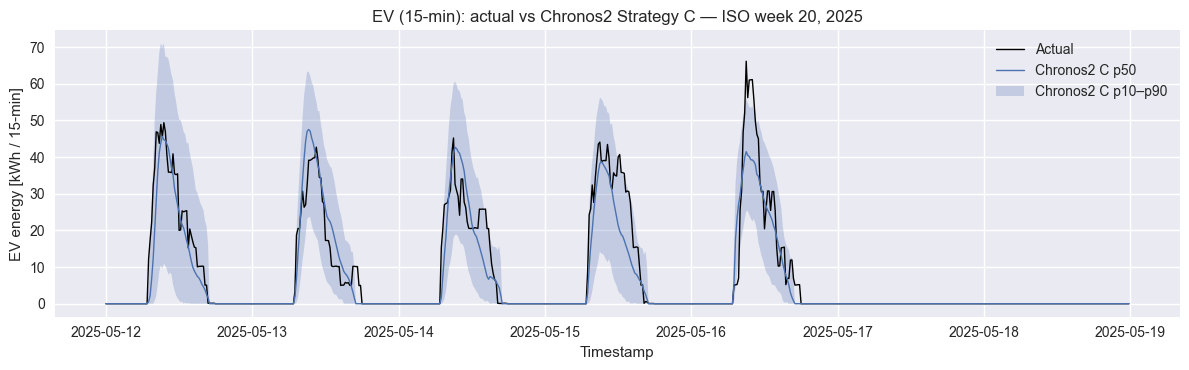

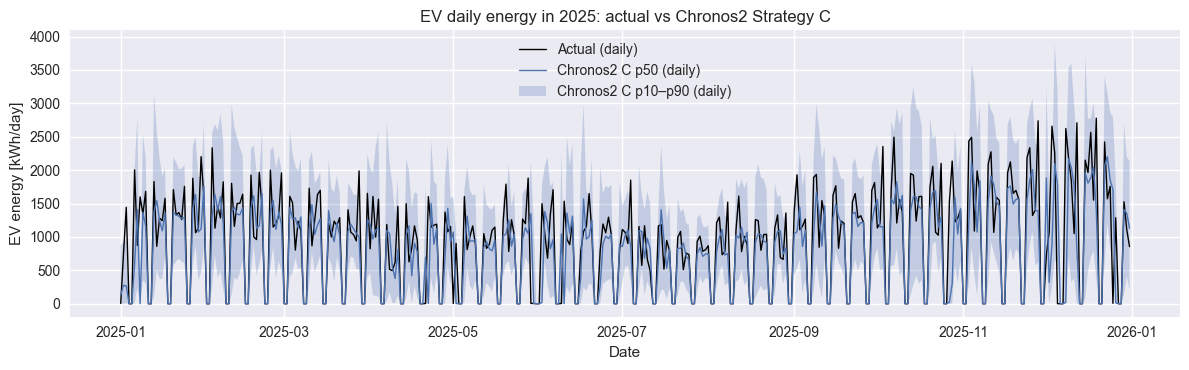

In [9]:
# Strategy C – Chronos2 no-foresight full-year forecast for 2025 (35040 values)
#
# Goal (MPC-safe): build a forecast series that can be sliced at any MPC step
# without using any future EV measurements.
#
# Approach (15-min rolling, no-foresight):
# - Forecast value at index k uses ONLY actual EV history up to k-1.
# - We still enforce EV window: weekdays 07:00–17:00; outside that window forecast is 0.
#
# Output:
# - df_2025["ev_forecast_2025_C"] (kWh per 15-min), length 35040.

import torch
from chronos import Chronos2Pipeline

# --- Parameters ---
CHRONOS2_MODEL_NAME = "amazon/chronos-2"  # public checkpoint used in notebook 08
CHRONOS2_CONTEXT_LENGTH = 14 * 96         # 14 days of 15-min context
CONTEXT_START = pd.Timestamp("2024-09-01 00:00:00")
BATCH_SIZE = 64                           # Chronos inference batch (tune for speed/RAM)

# Instantiate Chronos2
_device = "cuda" if torch.cuda.is_available() else "cpu"
chronos2 = Chronos2Pipeline.from_pretrained(
    CHRONOS2_MODEL_NAME,
    torch_dtype=torch.float32,
    device_map=_device,
)

# ----------------------------
# Build a regular-grid history series for context
# ----------------------------
# 1) 2024 context (Sept 2024 onward)
df_2024_sorted = df_2024.copy().sort_values("timestamp")
df_2024_sorted = df_2024_sorted[df_2024_sorted["timestamp"] >= CONTEXT_START].copy()

# 2) 2025 actuals (used as past-only history at each k)
_df_c = df_2025.copy().sort_values("timestamp").reset_index(drop=True)

n = len(_df_c)
if n != 35040:
    print(f"[WARN] Expected 35040 rows for 2025 (15-min), got n={n}.")

# Helper: enforce EV window on a timestamp series (keeps regular grid)
def _window_mask(ts: pd.Series) -> np.ndarray:
    tod = ts.dt.hour + ts.dt.minute / 60.0
    is_wd = ts.dt.dayofweek < 5
    in_w = (tod >= 7.0) & (tod < 17.0)
    return (is_wd & in_w).to_numpy(dtype=bool)

mask24 = _window_mask(df_2024_sorted["timestamp"])
mask25 = _window_mask(_df_c["timestamp"])

# Windowed actual series (outside EV window is 0 so spacing stays 15-min)
ev24 = df_2024_sorted["ev"].astype(float).to_numpy()
ev24 = np.where(mask24, ev24, 0.0).astype(np.float32)

ev25_actual = _df_c["ev"].astype(float).to_numpy()
ev25_actual = np.where(mask25, ev25_actual, 0.0).astype(np.float32)

# Full history array we can slice for any k (no leakage because we slice up to k-1)
hist_all = np.concatenate([ev24, ev25_actual])
offset_2025 = len(ev24)

# ----------------------------
# Chronos prediction extraction helper
# ----------------------------
def _extract_median_1d(pred_tensor: torch.Tensor) -> np.ndarray:
    arr = pred_tensor.detach().cpu().numpy()

    # Handle batch dim if present
    if arr.ndim == 3 and arr.shape[0] == 1:
        arr = arr[0]

    # Now expect (Q, H) or (1, H) or (H,)
    if arr.ndim == 2 and arr.shape[0] == 1:
        y_hat = arr[0]
    elif arr.ndim == 2:
        q_levels = getattr(chronos2, "quantiles", None)
        if isinstance(q_levels, list) and 0.5 in q_levels:
            med_i = q_levels.index(0.5)
            if arr.shape[0] == len(q_levels):
                y_hat = arr[med_i, :]
            elif arr.shape[1] == len(q_levels):
                y_hat = arr[:, med_i]
            else:
                y_hat = arr[arr.shape[0] // 2, :]
        else:
            # Fallback: pick middle row/col
            if arr.shape[0] <= arr.shape[1]:
                y_hat = arr[arr.shape[0] // 2, :]
            else:
                y_hat = arr[:, arr.shape[1] // 2]
    elif arr.ndim == 1:
        y_hat = arr
    else:
        raise ValueError(f"Unexpected Chronos2 prediction shape: {pred_tensor.shape} -> {arr.shape}")

    return np.clip(np.asarray(y_hat, dtype=float), 0.0, None)

# ----------------------------
# Build 35040×1 forecast with DAILY issuance at 07:00 (quantiles p10/p50/p90)
# ----------------------------
# For each weekday D in 2025:
# - At 07:00 we issue ONE forecast for the EV window of that day (07:00–17:00).
# - Use ONLY masked actual EV history strictly before 07:00 as context.
# - Outside the EV window (and weekends) forecast is 0.
#
# This avoids Chronos-2's model_prediction_length limit (1024) that blocks monthly full-grid horizons.

forecast_c_p10 = np.zeros(n, dtype=float)
forecast_c_p50 = np.zeros(n, dtype=float)
forecast_c_p90 = np.zeros(n, dtype=float)

_df_c["date"] = _df_c["timestamp"].dt.date
_tod = _df_c["timestamp"].dt.hour + _df_c["timestamp"].dt.minute / 60.0

dates = pd.Index(_df_c["date"].unique()).sort_values()
H_DAY = 40  # 07:00–17:00 = 10h = 40×15min

issue_days = []  # (date, k0, k1)
for d in dates:
    # weekday only
    if int(pd.Timestamp(d).dayofweek) >= 5:
        continue

    day_idxs = np.where((_df_c["date"] == d).to_numpy())[0]
    if len(day_idxs) == 0:
        continue

    # first 07:00 index in that day
    tod_d = _tod.iloc[day_idxs].to_numpy(dtype=float)
    at_0700 = day_idxs[np.isclose(tod_d, 7.0)]
    if len(at_0700) == 0:
        continue

    k0 = int(at_0700[0])
    k1 = k0 + H_DAY
    if k1 > n:
        continue

    issue_days.append((d, k0, k1))

# Batch multiple daily contexts per Chronos call
for start in range(0, len(issue_days), BATCH_SIZE):
    batch = issue_days[start : start + BATCH_SIZE]

    _days = [str(d) for (d, _, _) in batch]
    print(f"[Chronos2] Issuing daily 07:00 forecasts for: {_days[0]}{' ... ' + _days[-1] if len(_days) > 1 else ''} (n={len(_days)})")

    ctx_list = []
    for (d, k0, k1) in batch:
        end = offset_2025 + k0  # context strictly before 07:00
        ctx = hist_all[max(0, end - CHRONOS2_CONTEXT_LENGTH) : end].astype(np.float32)
        if len(ctx) < CHRONOS2_CONTEXT_LENGTH:
            ctx = np.concatenate(
                [np.zeros(CHRONOS2_CONTEXT_LENGTH - len(ctx), dtype=np.float32), ctx]
            )
        ctx_list.append(ctx)

    ctx_batch = np.stack(ctx_list, axis=0)
    ctx_t = torch.tensor(ctx_batch, dtype=torch.float32).view(len(batch), 1, -1)

    q, _mean = chronos2.predict_quantiles(
        inputs=ctx_t,
        prediction_length=H_DAY,
        quantile_levels=[0.1, 0.5, 0.9],
        limit_prediction_length=False,
    )

    def _q_to_p10_p50_p90(q_one: torch.Tensor) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        arr = q_one.detach().cpu().numpy()
        # Common shapes: (1, H, 3), (1, 3, H), (H, 3), (3, H)
        if arr.ndim == 3 and arr.shape[0] == 1:
            arr = arr[0]

        if arr.shape == (H_DAY, 3):
            p10, p50, p90 = arr[:, 0], arr[:, 1], arr[:, 2]
        elif arr.shape == (3, H_DAY):
            p10, p50, p90 = arr[0, :], arr[1, :], arr[2, :]
        elif arr.ndim == 2 and arr.shape[1] == 3 and arr.shape[0] == H_DAY:
            p10, p50, p90 = arr[:, 0], arr[:, 1], arr[:, 2]
        else:
            raise ValueError(f"Unexpected quantile shape per-series: {q_one.shape} -> {arr.shape}")

        p10 = np.clip(p10.astype(float), 0.0, None)
        p50 = np.clip(p50.astype(float), 0.0, None)
        p90 = np.clip(p90.astype(float), 0.0, None)
        return p10, p50, p90

    if isinstance(q, list):
        # list length should match batch
        if len(q) != len(batch):
            raise ValueError(f"Quantile list length {len(q)} != batch size {len(batch)}")
        for i, (d, k0, k1) in enumerate(batch):
            p10_i, p50_i, p90_i = _q_to_p10_p50_p90(q[i])
            forecast_c_p10[k0:k1] = p10_i
            forecast_c_p50[k0:k1] = p50_i
            forecast_c_p90[k0:k1] = p90_i
    else:
        # tensor batch output
        q_arr = q.detach().cpu().numpy()
        if q_arr.ndim != 3:
            raise ValueError(f"Unexpected quantile batch shape: {q_arr.shape}")

        # Convert to (B, H, 3)
        if q_arr.shape[1] == H_DAY and q_arr.shape[2] == 3:
            q_b = q_arr
        elif q_arr.shape[1] == 3 and q_arr.shape[2] == H_DAY:
            q_b = np.transpose(q_arr, (0, 2, 1))
        else:
            raise ValueError(f"Unexpected quantile batch shape: {q_arr.shape}")

        for i, (d, k0, k1) in enumerate(batch):
            p10_i = np.clip(q_b[i, :, 0].astype(float), 0.0, None)
            p50_i = np.clip(q_b[i, :, 1].astype(float), 0.0, None)
            p90_i = np.clip(q_b[i, :, 2].astype(float), 0.0, None)
            forecast_c_p10[k0:k1] = p10_i
            forecast_c_p50[k0:k1] = p50_i
            forecast_c_p90[k0:k1] = p90_i

# Safety: ensure outside EV window is 0
forecast_c_p10 = np.where(mask25, forecast_c_p10, 0.0)
forecast_c_p50 = np.where(mask25, forecast_c_p50, 0.0)
forecast_c_p90 = np.where(mask25, forecast_c_p90, 0.0)

_df_c["ev_forecast_2025_C_p10"] = forecast_c_p10
_df_c["ev_forecast_2025_C_p50"] = forecast_c_p50
_df_c["ev_forecast_2025_C_p90"] = forecast_c_p90

# Backward-compatible single series used elsewhere
_df_c["ev_forecast_2025_C"] = forecast_c_p50

df_2025 = _df_c

# Daily energy forecast (kWh/day) for Strategy C
ev_daily_energy_forecast_2025_C = df_2025.groupby("date")["ev_forecast_2025_C"].sum()

print(
    f"Chronos2 Strategy C added (rolling, no-foresight): df_2025['ev_forecast_2025_C'] "
    f"(model={CHRONOS2_MODEL_NAME}, device={_device}, context={CHRONOS2_CONTEXT_LENGTH})"
)
print("Nonzero forecast share:", float(np.mean(df_2025["ev_forecast_2025_C"].to_numpy() > 0.0)))

# ----------------------------
# Error metrics for Strategy C (p50)
# ----------------------------
_df_eval_C = df_2025.copy().sort_values("timestamp")

err_15 = _df_eval_C["ev_forecast_2025_C"] - _df_eval_C["ev"]
mae_15 = float(err_15.abs().mean())
rmse_15 = float(np.sqrt((err_15 ** 2).mean()))

_daily_act = _df_eval_C.groupby("date")["ev"].sum()
_daily_fc = _df_eval_C.groupby("date")["ev_forecast_2025_C"].sum()
err_day = _daily_fc - _daily_act
mae_day = float(err_day.abs().mean())
rmse_day = float(np.sqrt((err_day ** 2).mean()))

print("Strategy C (Chronos2) – 2025 EV demand forecast")
print("15-min level (kWh per 15-min):")
print(f"  MAE  = {mae_15:8.3f} kWh")
print(f"  RMSE = {rmse_15:8.3f} kWh")
print()
print("Daily energy level (kWh per day):")
print(f"  MAE  = {mae_day:8.3f} kWh")
print(f"  RMSE = {rmse_day:8.3f} kWh")

# Visualisation for Strategy C quantiles (p10/p50/p90): ISO week + yearly view

import matplotlib.pyplot as plt

# --- Parameters ---
ISO_WEEK_YEAR_C = 2025
ISO_WEEK_C = 20

required_cols = [
    "ev_forecast_2025_C_p10",
    "ev_forecast_2025_C_p50",
    "ev_forecast_2025_C_p90",
]
for c in required_cols:
    if c not in df_2025.columns:
        raise ValueError(f"Missing df_2025[{c!r}]. Run Strategy C cell first.")

_df = df_2025.copy().sort_values("timestamp")
iso = _df["timestamp"].dt.isocalendar()
mask_week = (iso["year"] == ISO_WEEK_YEAR_C) & (iso["week"] == ISO_WEEK_C)
week_df = _df.loc[mask_week]

if week_df.empty:
    raise ValueError(f"No data found for ISO week {ISO_WEEK_C}, {ISO_WEEK_YEAR_C}.")

# --- Plot 1: ISO week 15-min overlay ---
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(week_df["timestamp"], week_df["ev"], label="Actual", lw=1.0, color="black")
ax.plot(week_df["timestamp"], week_df["ev_forecast_2025_C_p50"], label="Chronos2 C p50", lw=1.0)
ax.fill_between(
    week_df["timestamp"],
    week_df["ev_forecast_2025_C_p10"],
    week_df["ev_forecast_2025_C_p90"],
    alpha=0.25,
    label="Chronos2 C p10–p90",
)
ax.set_title(f"EV (15-min): actual vs Chronos2 Strategy C — ISO week {ISO_WEEK_C}, {ISO_WEEK_YEAR_C}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("EV energy [kWh / 15-min]")
ax.grid(True)
ax.legend()
plt.tight_layout()

# --- Plot 2: Yearly daily energy (kWh/day) with quantile band ---
_df["date"] = _df["timestamp"].dt.date

daily_act = _df.groupby("date")["ev"].sum()
daily_p10 = _df.groupby("date")["ev_forecast_2025_C_p10"].sum()
daily_p50 = _df.groupby("date")["ev_forecast_2025_C_p50"].sum()
daily_p90 = _df.groupby("date")["ev_forecast_2025_C_p90"].sum()

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(daily_act.index, daily_act.values, label="Actual (daily)", lw=1.0, color="black")
ax.plot(daily_p50.index, daily_p50.values, label="Chronos2 C p50 (daily)", lw=1.0)
ax.fill_between(daily_p50.index, daily_p10.values, daily_p90.values, alpha=0.25, label="Chronos2 C p10–p90 (daily)")
ax.set_title("EV daily energy in 2025: actual vs Chronos2 Strategy C")
ax.set_xlabel("Date")
ax.set_ylabel("EV energy [kWh/day]")
ax.grid(True)
ax.legend()
plt.tight_layout()


## Part 3 – Forecast evaluation and visualization

In this section we compare forecasted EV profiles against actual uncontrolled EV charging:

- Compute error metrics for Strategies A  on 2025 (15-minute and daily levels).
- Plot representative daily, weekly, monthly, and yearly summaries for visual inspection.

### 3.1 Error metrics for Strategy A

We evaluate **Strategy A (same time last week)** on 2025 by computing error metrics at the 15‑minute level and on aggregated daily energy.

In [10]:
# Error metrics for Strategy A on 2025

# Ensure the required columns exist
assert "ev" in df_2025.columns, "df_2025 must contain the actual EV column 'ev'"
assert "ev_forecast_2025" in df_2025.columns, "Run Strategy A cell first to create 'ev_forecast_2025'"

_df_eval = df_2025.copy().sort_values("timestamp")

# 15-min errors (kWh per interval)
_df_eval["error_15min"] = _df_eval["ev_forecast_2025"] - _df_eval["ev"]

mae_15min = _df_eval["error_15min"].abs().mean()
rmse_15min = np.sqrt((_df_eval["error_15min"] ** 2).mean())

# Daily energy errors (kWh per day)
_daily_actual_2025 = _df_eval.groupby("date")["ev"].sum()
_daily_forecast_2025 = _df_eval.groupby("date")["ev_forecast_2025"].sum()

_daily_error = _daily_forecast_2025 - _daily_actual_2025

mae_daily = _daily_error.abs().mean()
rmse_daily = np.sqrt((_daily_error ** 2).mean())

print("Strategy A – 2025 EV demand forecast")
print("15-min level (kWh per 15-min):")
print(f"  MAE  = {mae_15min:8.3f} kWh")
print(f"  RMSE = {rmse_15min:8.3f} kWh")
print()
print("Daily energy level (kWh per day):")
print(f"  MAE  = {mae_daily:8.3f} kWh")
print(f"  RMSE = {rmse_daily:8.3f} kWh")

Strategy A – 2025 EV demand forecast
15-min level (kWh per 15-min):
  MAE  =    4.734 kWh
  RMSE =   11.790 kWh

Daily energy level (kWh per day):
  MAE  =  296.293 kWh
  RMSE =  511.397 kWh


### 3.2 Strategy B – Choosing K

To select an appropriate **K** for Strategy B, we compare forecast accuracy across K=1..16 using 15‑minute and daily error metrics (MAE, RMSE) and visualize how these metrics change with K.

Strategy B – forecast accuracy vs K (+A, +C)


,MAE_15min,RMSE_15min,MAE_daily,RMSE_daily,MAE_envelope,RMSE_envelope
K,,,,,,
1,4.790054,12.017641,304.511177,525.658613,24.123071,62.867262
2,4.181533,10.418346,264.297841,449.597934,21.161454,55.182678
3,3.824996,9.468588,232.910840,401.884695,19.292820,49.397353
4,3.707475,9.215243,227.900700,388.991101,18.587487,47.822940
5,3.673848,9.095875,226.225380,384.093174,18.594774,47.632129
6,3.673669,9.092809,231.681980,387.327604,18.697171,47.606334
7,3.667652,9.079818,234.803096,388.938933,18.871820,47.666395
8,3.619885,8.995797,237.228894,389.542688,18.919356,47.917891
9,3.623852,9.018984,238.318652,390.906728,19.053620,47.961472


Strategy B – forecast accuracy vs K


,MAE_15min,RMSE_15min,MAE_daily,RMSE_daily,MAE_envelope,RMSE_envelope
K,,,,,,
1,4.790054,12.017641,304.511177,525.658613,24.123071,62.867262
2,4.181533,10.418346,264.297841,449.597934,21.161454,55.182678
3,3.824996,9.468588,232.910840,401.884695,19.292820,49.397353
4,3.707475,9.215243,227.900700,388.991101,18.587487,47.822940
5,3.673848,9.095875,226.225380,384.093174,18.594774,47.632129
6,3.673669,9.092809,231.681980,387.327604,18.697171,47.606334
7,3.667652,9.079818,234.803096,388.938933,18.871820,47.666395
8,3.619885,8.995797,237.228894,389.542688,18.919356,47.917891
9,3.623852,9.018984,238.318652,390.906728,19.053620,47.961472


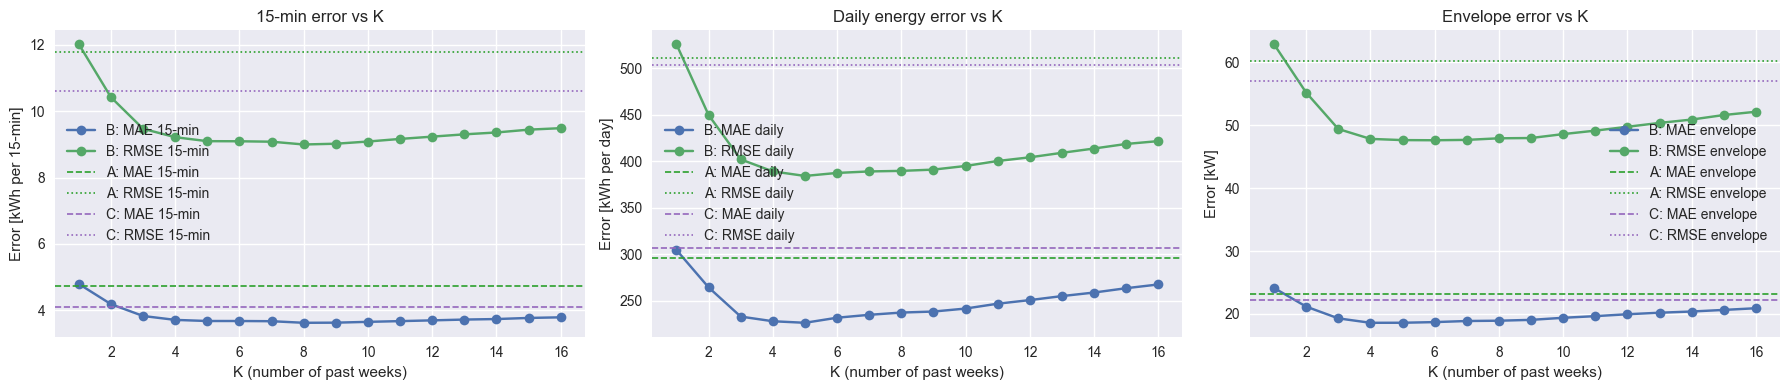

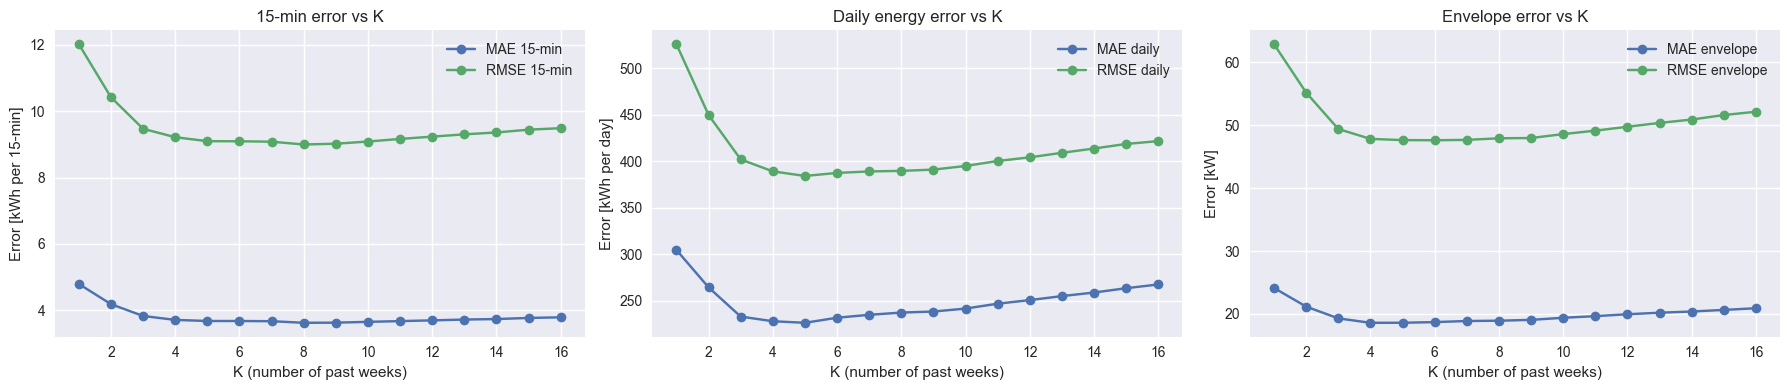

In [11]:
# Error metrics vs K for Strategy B (B1..B16)
# + include Strategy A and Strategy C (Chronos2) in the table

K_VALUES_B = list(range(1, 17))  # 1..16

_df_eval_B = df_2025.copy().sort_values("timestamp")
_df_eval_B["date"] = _df_eval_B["timestamp"].dt.date

# Precompute daily actual energy once
_daily_actual_2025_B = _df_eval_B.groupby("date")["ev"].sum()

# Helper: compute EV power envelope (kW) from 15-min energy (kWh/interval)
def compute_ev_envelope(ev_kwh: np.ndarray, timestamps: pd.Series) -> np.ndarray:
    power_kw = ev_kwh * 4.0
    time_of_day = timestamps.dt.hour + timestamps.dt.minute / 60.0
    dates = timestamps.dt.date.values

    envelope = np.zeros_like(power_kw)
    unique_dates = np.unique(dates)

    for d in unique_dates:
        mask = dates == d
        idx = np.where(mask)[0]
        day_power = power_kw[idx]
        day_tod = time_of_day.iloc[idx].values

        cum_max = np.maximum.accumulate(day_power)

        before_1530 = day_tod <= 15.5
        if np.any(before_1530):
            last_1530_idx = np.where(before_1530)[0][-1]
            p_max_1530 = cum_max[last_1530_idx]
        else:
            p_max_1530 = cum_max[0] if len(cum_max) > 0 else 0.0

        for i_local, t_hour in enumerate(day_tod):
            i_global = idx[i_local]
            if t_hour <= 15.5:
                envelope[i_global] = cum_max[i_local]
            elif 15.5 < t_hour < 17.0:
                envelope[i_global] = p_max_1530 * (17.0 - t_hour) / 1.5
            else:
                envelope[i_global] = 0.0

    return envelope

# Actual envelope from uncontrolled EV
env_actual = compute_ev_envelope(_df_eval_B["ev"].to_numpy(), _df_eval_B["timestamp"])

# Strategy B metrics
rows = []
for k in K_VALUES_B:
    col = f"ev_forecast_2025_B{k}"
    assert col in _df_eval_B.columns, f"Missing forecast column {col}; run Strategy B cell first."

    err_15 = _df_eval_B[col] - _df_eval_B["ev"]
    mae_15 = err_15.abs().mean()
    rmse_15 = np.sqrt((err_15 ** 2).mean())

    daily_forecast = _df_eval_B.groupby("date")[col].sum()
    daily_err = daily_forecast - _daily_actual_2025_B
    mae_day = daily_err.abs().mean()
    rmse_day = np.sqrt((daily_err ** 2).mean())

    env_forecast = compute_ev_envelope(_df_eval_B[col].to_numpy(), _df_eval_B["timestamp"])
    env_err = env_forecast - env_actual
    mae_env = np.mean(np.abs(env_err))
    rmse_env = np.sqrt(np.mean(env_err ** 2))

    rows.append(
        {
            "K": k,
            "MAE_15min": mae_15,
            "RMSE_15min": rmse_15,
            "MAE_daily": mae_day,
            "RMSE_daily": rmse_day,
            "MAE_envelope": mae_env,
            "RMSE_envelope": rmse_env,
        }
    )

metrics_B = pd.DataFrame(rows).set_index("K")

# Strategy A/C metrics
def _metrics_for_col(col: str):
    if col not in _df_eval_B.columns:
        return None

    err_15 = _df_eval_B[col] - _df_eval_B["ev"]
    mae_15 = err_15.abs().mean()
    rmse_15 = np.sqrt((err_15 ** 2).mean())

    daily_forecast = _df_eval_B.groupby("date")[col].sum()
    daily_err = daily_forecast - _daily_actual_2025_B
    mae_day = daily_err.abs().mean()
    rmse_day = np.sqrt((daily_err ** 2).mean())

    env_forecast = compute_ev_envelope(_df_eval_B[col].to_numpy(), _df_eval_B["timestamp"])
    env_err = env_forecast - env_actual
    mae_env = np.mean(np.abs(env_err))
    rmse_env = np.sqrt(np.mean(env_err ** 2))

    return {
        "MAE_15min": mae_15,
        "RMSE_15min": rmse_15,
        "MAE_daily": mae_day,
        "RMSE_daily": rmse_day,
        "MAE_envelope": mae_env,
        "RMSE_envelope": rmse_env,
    }

m_A = _metrics_for_col("ev_forecast_2025")
m_C = _metrics_for_col("ev_forecast_2025_C")

metrics_compare = metrics_B.copy()
if m_A is not None:
    metrics_compare.loc["A"] = m_A
if m_C is not None:
    metrics_compare.loc["C"] = m_C

print("Strategy B – forecast accuracy vs K (+A, +C)")
display(metrics_compare)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Panel 1: 15-min metrics vs K
ax = axes[0]
ax.plot(metrics_B.index, metrics_B["MAE_15min"], marker="o", label="B: MAE 15-min")
ax.plot(metrics_B.index, metrics_B["RMSE_15min"], marker="o", label="B: RMSE 15-min")
if m_A is not None:
    ax.axhline(m_A["MAE_15min"], color="tab:green", linestyle="--", linewidth=1.2, label="A: MAE 15-min")
    ax.axhline(m_A["RMSE_15min"], color="tab:green", linestyle=":", linewidth=1.2, label="A: RMSE 15-min")
if m_C is not None:
    ax.axhline(m_C["MAE_15min"], color="tab:purple", linestyle="--", linewidth=1.2, label="C: MAE 15-min")
    ax.axhline(m_C["RMSE_15min"], color="tab:purple", linestyle=":", linewidth=1.2, label="C: RMSE 15-min")
ax.set_xlabel("K (number of past weeks)")
ax.set_ylabel("Error [kWh per 15-min]")
ax.set_title("15-min error vs K")
ax.grid(True)
ax.legend()

# Panel 2: daily metrics vs K
ax = axes[1]
ax.plot(metrics_B.index, metrics_B["MAE_daily"], marker="o", label="B: MAE daily")
ax.plot(metrics_B.index, metrics_B["RMSE_daily"], marker="o", label="B: RMSE daily")
if m_A is not None:
    ax.axhline(m_A["MAE_daily"], color="tab:green", linestyle="--", linewidth=1.2, label="A: MAE daily")
    ax.axhline(m_A["RMSE_daily"], color="tab:green", linestyle=":", linewidth=1.2, label="A: RMSE daily")
if m_C is not None:
    ax.axhline(m_C["MAE_daily"], color="tab:purple", linestyle="--", linewidth=1.2, label="C: MAE daily")
    ax.axhline(m_C["RMSE_daily"], color="tab:purple", linestyle=":", linewidth=1.2, label="C: RMSE daily")
ax.set_xlabel("K (number of past weeks)")
ax.set_ylabel("Error [kWh per day]")
ax.set_title("Daily energy error vs K")
ax.grid(True)
ax.legend()

# Panel 3: envelope metrics vs K (kW)
ax = axes[2]
ax.plot(metrics_B.index, metrics_B["MAE_envelope"], marker="o", label="B: MAE envelope")
ax.plot(metrics_B.index, metrics_B["RMSE_envelope"], marker="o", label="B: RMSE envelope")
if m_A is not None:
    ax.axhline(m_A["MAE_envelope"], color="tab:green", linestyle="--", linewidth=1.2, label="A: MAE envelope")
    ax.axhline(m_A["RMSE_envelope"], color="tab:green", linestyle=":", linewidth=1.2, label="A: RMSE envelope")
if m_C is not None:
    ax.axhline(m_C["MAE_envelope"], color="tab:purple", linestyle="--", linewidth=1.2, label="C: MAE envelope")
    ax.axhline(m_C["RMSE_envelope"], color="tab:purple", linestyle=":", linewidth=1.2, label="C: RMSE envelope")
ax.set_xlabel("K (number of past weeks)")
ax.set_ylabel("Error [kW]")
ax.set_title("Envelope error vs K")
ax.grid(True)
ax.legend()

plt.tight_layout()

# Helper: compute EV power envelope (kW) from 15-min energy (kWh/interval)
def compute_ev_envelope(ev_kwh: np.ndarray, timestamps: pd.Series) -> np.ndarray:
    power_kw = ev_kwh * 4.0
    time_of_day = timestamps.dt.hour + timestamps.dt.minute / 60.0
    dates = timestamps.dt.date.values

    envelope = np.zeros_like(power_kw)
    unique_dates = np.unique(dates)

    for d in unique_dates:
        mask = dates == d
        idx = np.where(mask)[0]
        day_power = power_kw[idx]
        day_tod = time_of_day.iloc[idx].values

        cum_max = np.maximum.accumulate(day_power)

        before_1530 = day_tod <= 15.5
        if np.any(before_1530):
            last_1530_idx = np.where(before_1530)[0][-1]
            p_max_1530 = cum_max[last_1530_idx]
        else:
            p_max_1530 = cum_max[0] if len(cum_max) > 0 else 0.0

        for i_local, t_hour in enumerate(day_tod):
            i_global = idx[i_local]
            if t_hour <= 15.5:
                envelope[i_global] = cum_max[i_local]
            elif 15.5 < t_hour < 17.0:
                envelope[i_global] = p_max_1530 * (17.0 - t_hour) / 1.5
            else:
                envelope[i_global] = 0.0

    return envelope

# Actual envelope from uncontrolled EV
env_actual = compute_ev_envelope(_df_eval_B["ev"].to_numpy(), _df_eval_B["timestamp"])

rows = []
for k in K_VALUES_B:
    col = f"ev_forecast_2025_B{k}"
    assert col in _df_eval_B.columns, f"Missing forecast column {col}; run Strategy B cell first."

    # 15-min errors
    err_15 = _df_eval_B[col] - _df_eval_B["ev"]
    mae_15 = err_15.abs().mean()
    rmse_15 = np.sqrt((err_15 ** 2).mean())

    # Daily errors
    daily_forecast = _df_eval_B.groupby("date")[col].sum()
    daily_err = daily_forecast - _daily_actual_2025_B
    mae_day = daily_err.abs().mean()
    rmse_day = np.sqrt((daily_err ** 2).mean())

    # Envelope errors (kW)
    env_forecast = compute_ev_envelope(_df_eval_B[col].to_numpy(), _df_eval_B["timestamp"])
    env_err = env_forecast - env_actual
    mae_env = np.mean(np.abs(env_err))
    rmse_env = np.sqrt(np.mean(env_err ** 2))

    rows.append({
        "K": k,
        "MAE_15min": mae_15,
        "RMSE_15min": rmse_15,
        "MAE_daily": mae_day,
        "RMSE_daily": rmse_day,
        "MAE_envelope": mae_env,
        "RMSE_envelope": rmse_env,
    })

metrics_B = pd.DataFrame(rows).set_index("K")
print("Strategy B – forecast accuracy vs K")
display(metrics_B)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Panel 1: 15-min metrics vs K
ax = axes[0]
ax.plot(metrics_B.index, metrics_B["MAE_15min"], marker="o", label="MAE 15-min")
ax.plot(metrics_B.index, metrics_B["RMSE_15min"], marker="o", label="RMSE 15-min")
ax.set_xlabel("K (number of past weeks)")
ax.set_ylabel("Error [kWh per 15-min]")
ax.set_title("15-min error vs K")
ax.grid(True)
ax.legend()

# Panel 2: daily metrics vs K
ax = axes[1]
ax.plot(metrics_B.index, metrics_B["MAE_daily"], marker="o", label="MAE daily")
ax.plot(metrics_B.index, metrics_B["RMSE_daily"], marker="o", label="RMSE daily")
ax.set_xlabel("K (number of past weeks)")
ax.set_ylabel("Error [kWh per day]")
ax.set_title("Daily energy error vs K")
ax.grid(True)
ax.legend()

# Panel 3: envelope metrics vs K (kW)
ax = axes[2]
ax.plot(metrics_B.index, metrics_B["MAE_envelope"], marker="o", label="MAE envelope")
ax.plot(metrics_B.index, metrics_B["RMSE_envelope"], marker="o", label="RMSE envelope")
ax.set_xlabel("K (number of past weeks)")
ax.set_ylabel("Error [kW]")
ax.set_title("Envelope error vs K")
ax.grid(True)
ax.legend()

plt.tight_layout()

### 3.3 Envelope visualization for selected strategy

Here we inspect the **EV power envelopes (kW)** for a selected strategy (A, B2, B3, …) on a representative **week and day**, to see how well the forecast-derived envelope matches the actual uncontrolled envelope.

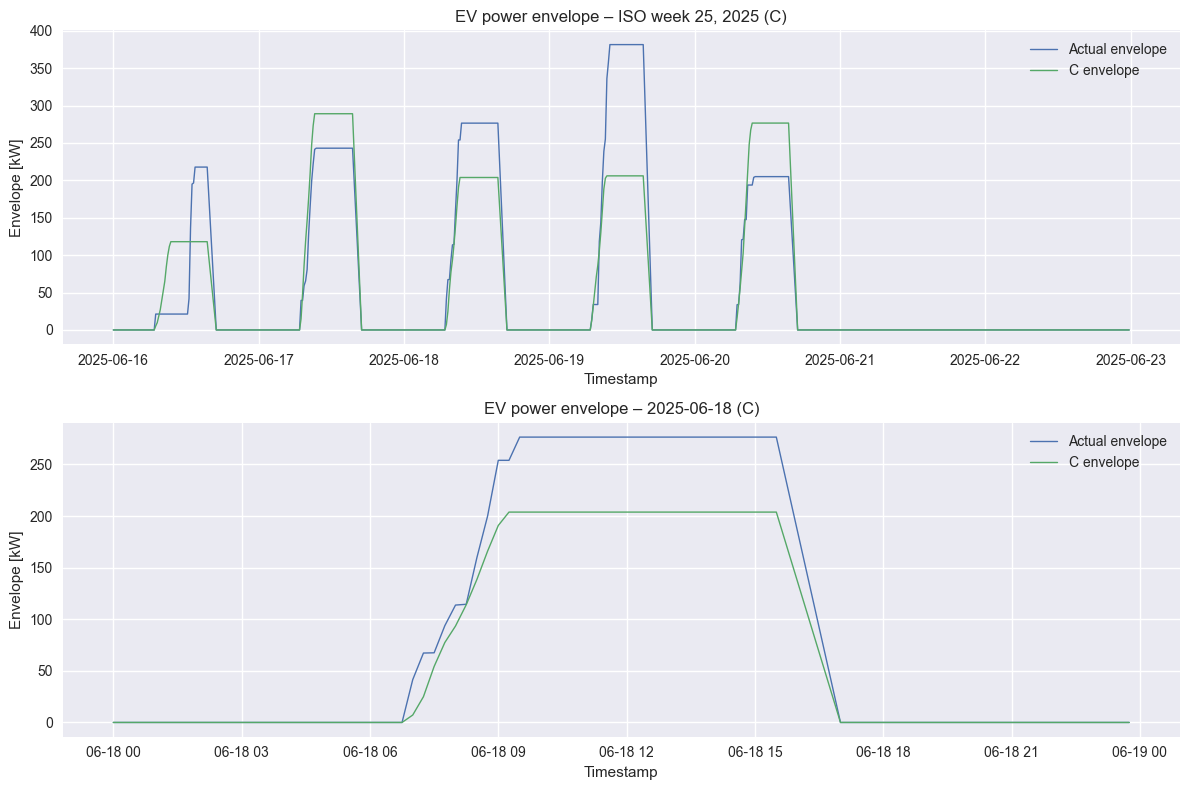

In [12]:
# Envelope visualization for a selected strategy (A, B2, B3, ...)

# --- Parameters ---
# Strategy label: "A" for Strategy A, or "B5" for Strategy B with K=5, etc.
strategy_label = "C"

# ISO week selection (same convention as before)
week_year_env = 2025
week_number_env = 25
# Day-of-week within that ISO week: 1=Mon, ..., 7=Sun
weekday_env = 3

_df_env = df_2025.copy().sort_values("timestamp")
iso_env = _df_env["timestamp"].dt.isocalendar()

# Choose forecast column based on strategy label
if strategy_label == "A":
    forecast_col = "ev_forecast_2025"
elif strategy_label == "C":
    forecast_col = "ev_forecast_2025_C"
else:
    if not strategy_label.startswith("B"):
        raise ValueError("strategy_label must be 'A', 'C', or like 'B5', 'B3', ...")
    k_val = int(strategy_label[1:])
    forecast_col = f"ev_forecast_2025_B{k_val}"

if forecast_col not in _df_env.columns:
    raise ValueError(
        f"Forecast column '{forecast_col}' not found. Run Strategy A/B/C cells first."
    )

# Helper: envelope computation (reuse if already defined)
def compute_ev_envelope(ev_kwh: np.ndarray, timestamps: pd.Series) -> np.ndarray:
    power_kw = ev_kwh * 4.0
    time_of_day = timestamps.dt.hour + timestamps.dt.minute / 60.0
    dates = timestamps.dt.date.values

    envelope = np.zeros_like(power_kw)
    unique_dates = np.unique(dates)

    for d in unique_dates:
        mask = dates == d
        idx = np.where(mask)[0]
        day_power = power_kw[idx]
        day_tod = time_of_day.iloc[idx].values

        cum_max = np.maximum.accumulate(day_power)

        before_1530 = day_tod <= 15.5
        if np.any(before_1530):
            last_1530_idx = np.where(before_1530)[0][-1]
            p_max_1530 = cum_max[last_1530_idx]
        else:
            p_max_1530 = cum_max[0] if len(cum_max) > 0 else 0.0

        for i_local, t_hour in enumerate(day_tod):
            i_global = idx[i_local]
            if t_hour <= 15.5:
                envelope[i_global] = cum_max[i_local]
            elif 15.5 < t_hour < 17.0:
                envelope[i_global] = p_max_1530 * (17.0 - t_hour) / 1.5
            else:
                envelope[i_global] = 0.0

    return envelope

# Filter to selected ISO week and weekday
mask_week_env = (iso_env["year"] == week_year_env) & (iso_env["week"] == week_number_env)
_df_week_env = _df_env.loc[mask_week_env].copy()

if _df_week_env.empty:
    raise ValueError(f"No data found for ISO week {week_number_env}, {week_year_env}.")

# Week-level envelopes
env_actual_week = compute_ev_envelope(_df_week_env["ev"].to_numpy(), _df_week_env["timestamp"])
env_forecast_week = compute_ev_envelope(_df_week_env[forecast_col].to_numpy(), _df_week_env["timestamp"])

# Day within that week
iso_week_subset = _df_week_env["timestamp"].dt.isocalendar()
mask_day_env = iso_week_subset["day"] == weekday_env
_df_day_env = _df_week_env.loc[mask_day_env].copy()

if _df_day_env.empty:
    raise ValueError(f"No data found for weekday {weekday_env} in ISO week {week_number_env}, {week_year_env}.")

env_actual_day = compute_ev_envelope(_df_day_env["ev"].to_numpy(), _df_day_env["timestamp"])
env_forecast_day = compute_ev_envelope(_df_day_env[forecast_col].to_numpy(), _df_day_env["timestamp"])

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top: week envelopes
ax = axes[0]
ax.plot(_df_week_env["timestamp"], env_actual_week, label="Actual envelope", linewidth=1.0)
ax.plot(_df_week_env["timestamp"], env_forecast_week, label=f"{strategy_label} envelope", linewidth=1.0)
ax.set_title(f"EV power envelope – ISO week {week_number_env}, {week_year_env} ({strategy_label})")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Envelope [kW]")
ax.legend()
ax.grid(True)

# Bottom: day envelopes
rep_date_env = _df_day_env["timestamp"].dt.date.iloc[0]
ax = axes[1]
ax.plot(_df_day_env["timestamp"], env_actual_day, label="Actual envelope", linewidth=1.0)
ax.plot(_df_day_env["timestamp"], env_forecast_day, label=f"{strategy_label} envelope", linewidth=1.0)
ax.set_title(f"EV power envelope – {rep_date_env} ({strategy_label})")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Envelope [kW]")
ax.legend()
ax.grid(True)

plt.tight_layout()

### 3.4 Visual comparison of actual vs forecast

We now compare **actual vs selected strategy forecast** at different horizons (choose strategy in the code cell below, e.g. `"A"` or `"B5"`):

- A **representative day** (15‑minute profiles).
- A **representative week** (15‑minute profiles).
- **Monthly totals** over 2025.
- **Daily totals over the full year** (yearly view).

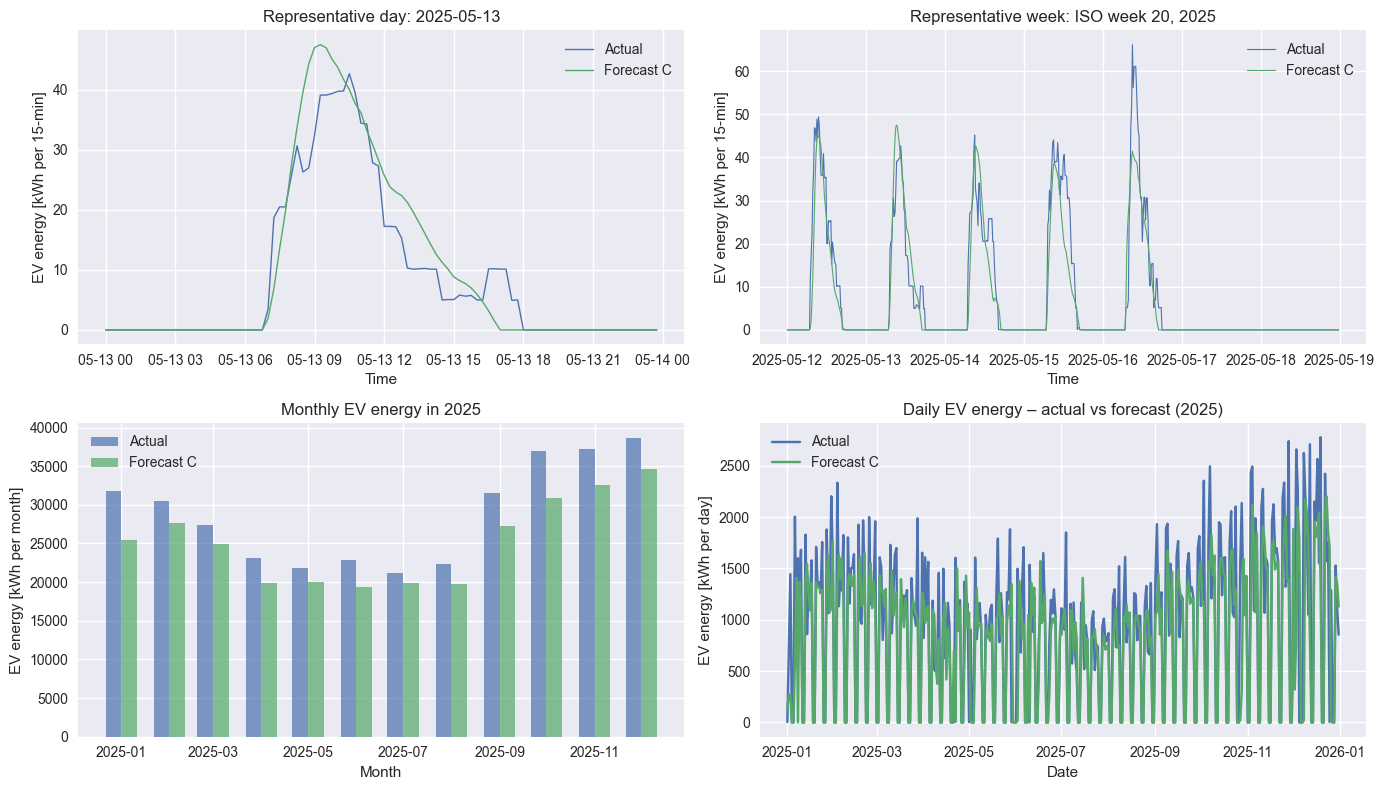

In [13]:
# Visual comparison plots for selected strategy (actual vs forecast)
# --- Select strategy to visualise (same as 3.3): "A" or "B2", "B5", etc. ---
strategy_label = "C"

_df_plot = df_2025.copy().sort_values("timestamp")
_df_plot["date"] = _df_plot["timestamp"].dt.date
_df_plot["time_of_day"] = _df_plot["timestamp"].dt.hour + _df_plot["timestamp"].dt.minute / 60.0

# Choose forecast column based on strategy label
if strategy_label == "A":
    forecast_col = "ev_forecast_2025"
elif strategy_label == "C":
    forecast_col = "ev_forecast_2025_C"
else:
    if not strategy_label.startswith("B"):
        raise ValueError("strategy_label must be 'A', 'C', or like 'B5', 'B3', ...")
    k_val = int(strategy_label[1:])
    forecast_col = f"ev_forecast_2025_B{k_val}"
if forecast_col not in _df_plot.columns:
    raise ValueError(
        f"Forecast column '{forecast_col}' not found. Run Strategy A/B/C cells first."
    )

# --- Parameters: choose representative day and/or week (set to None for auto) ---
# Example usage:
#   rep_day_param = datetime.date(2025, 5, 15)
#   rep_week_year_param = 2025
#   rep_week_param = 20
#   rep_day_of_week_param = 1  # 1=Mon, ..., 7=Sun within that ISO week
rep_day_param = None             # type: Optional[datetime.date]
rep_week_year_param = 2025       # type: Optional[int]
rep_week_param = 20              # type: Optional[int]
rep_day_of_week_param = 2        # type: Optional[int], 1=Mon .. 7=Sun

# ISO calendar for all timestamps
iso = _df_plot["timestamp"].dt.isocalendar()

# ---- Pick representative day ----
nonzero_days_2025 = _df_plot.groupby("date")["ev"].sum()
rep_day = None

# Priority 1: explicit calendar date
if rep_day_param is not None:
    rep_day = rep_day_param
# Priority 2: year+week+weekday selection
elif (
    rep_week_year_param is not None
    and rep_week_param is not None
    and rep_day_of_week_param is not None
):
    mask_target = (
        (iso["year"] == int(rep_week_year_param))
        & (iso["week"] == int(rep_week_param))
        & (iso["day"] == int(rep_day_of_week_param))
    )
    if mask_target.any():
        rep_day = _df_plot.loc[mask_target, "date"].iloc[0]

# Fallbacks
if rep_day is None:
    if (nonzero_days_2025 > 0).any():
        rep_day = nonzero_days_2025[nonzero_days_2025 > 0].index.min()
    else:
        rep_day = _df_plot["date"].min()

mask_day = _df_plot["date"] == rep_day
_day = _df_plot.loc[mask_day]

# ---- Pick representative week ----
if rep_week_year_param is not None and rep_week_param is not None:
    rep_year = int(rep_week_year_param)
    rep_week = int(rep_week_param)
else:
    rep_year = int(iso.loc[mask_day, "year"].iloc[0])
    rep_week = int(iso.loc[mask_day, "week"].iloc[0])

mask_week = (iso["year"] == rep_year) & (iso["week"] == rep_week)
_week = _df_plot.loc[mask_week]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1) Daily 15-min profile
ax = axes[0, 0]
ax.plot(_day["timestamp"], _day["ev"], label="Actual", linewidth=1.0)
ax.plot(_day["timestamp"], _day[forecast_col], label=f"Forecast {strategy_label}", linewidth=1.0)
ax.set_title(f"Representative day: {rep_day}")
ax.set_xlabel("Time")
ax.set_ylabel("EV energy [kWh per 15-min]")
ax.legend()
ax.grid(True)

# 2) Weekly 15-min profile
ax = axes[0, 1]
ax.plot(_week["timestamp"], _week["ev"], label="Actual", linewidth=0.8)
ax.plot(_week["timestamp"], _week[forecast_col], label=f"Forecast {strategy_label}", linewidth=0.8)
ax.set_title(f"Representative week: ISO week {rep_week}, {rep_year}")
ax.set_xlabel("Time")
ax.set_ylabel("EV energy [kWh per 15-min]")
ax.legend()
ax.grid(True)

# 3) Monthly totals (kWh)
_monthly_actual = _df_plot.groupby(_df_plot["timestamp"].dt.to_period("M"))["ev"].sum()
_monthly_forecast = _df_plot.groupby(_df_plot["timestamp"].dt.to_period("M"))[forecast_col].sum()

months = _monthly_actual.index.to_timestamp()
ax = axes[1, 0]
width = 10  # days, for visual separation in bar plot
ax.bar(months - pd.Timedelta(days=width/2), _monthly_actual.values,
       width=width, label="Actual", alpha=0.7)
ax.bar(months + pd.Timedelta(days=width/2), _monthly_forecast.values,
       width=width, label=f"Forecast {strategy_label}", alpha=0.7)
ax.set_title("Monthly EV energy in 2025")
ax.set_xlabel("Month")
ax.set_ylabel("EV energy [kWh per month]")
ax.legend()
ax.grid(True, axis="y")

# 4) Daily totals over full year (yearly view)
_daily_actual_2025 = _df_plot.groupby("date")["ev"].sum()
_daily_forecast_2025 = _df_plot.groupby("date")[forecast_col].sum()

ax = axes[1, 1]
ax.plot(_daily_actual_2025.index, _daily_actual_2025.values, label="Actual")
ax.plot(_daily_forecast_2025.index, _daily_forecast_2025.values, label=f"Forecast {strategy_label}")
ax.set_title("Daily EV energy – actual vs forecast (2025)")
ax.set_xlabel("Date")
ax.set_ylabel("EV energy [kWh per day]")
ax.legend()
ax.grid(True)

plt.tight_layout()

In [14]:
# Export EV forecasts to CSV (df_2025 has exactly 35040 rows; no DST duplicates)
# Use timestamps from plant1.csv as-is (with +01:00/+02:00) so format matches plant1.
OUTPUT_DIR = Path("../output")
FORECAST_DIR = OUTPUT_DIR / "forecast"
FORECAST_DIR.mkdir(parents=True, exist_ok=True)
FORECAST_EV_PATH = FORECAST_DIR / "forecast_ev_rolling_horizon.csv"

# Copy timestamps from plant1.csv (same order as df_2025, which is loaded from plant1)
_plant1 = pd.read_csv(DATA_2025_PATH)
export_df = pd.DataFrame({"timestamp": _plant1["timestamp"].values})
export_df["forecast_ev_a"] = df_2025["ev_forecast_2025"].values
for k in K_VALUES_B:
    export_df[f"forecast_ev_b{k}"] = df_2025[f"ev_forecast_2025_B{k}"].values

# Chronos2 Strategy C (quantiles). Use p50 as the default series for MPC.
if "ev_forecast_2025_C_p50" in df_2025.columns:
    export_df["forecast_ev_c"] = df_2025["ev_forecast_2025_C_p50"].values
if "ev_forecast_2025_C_p10" in df_2025.columns:
    export_df["forecast_ev_c_p10"] = df_2025["ev_forecast_2025_C_p10"].values
if "ev_forecast_2025_C_p90" in df_2025.columns:
    export_df["forecast_ev_c_p90"] = df_2025["ev_forecast_2025_C_p90"].values

export_df.to_csv(FORECAST_EV_PATH, index=False)
print(f"Exported {len(export_df)} rows to {FORECAST_EV_PATH}")
export_df.head()

Exported 35040 rows to ..\output\forecast\forecast_ev_rolling_horizon.csv


,timestamp,forecast_ev_a,forecast_ev_b1,forecast_ev_b2,forecast_ev_b3,forecast_ev_b4,forecast_ev_b5,forecast_ev_b6,forecast_ev_b7,forecast_ev_b8,...,forecast_ev_b10,forecast_ev_b11,forecast_ev_b12,forecast_ev_b13,forecast_ev_b14,forecast_ev_b15,forecast_ev_b16,forecast_ev_c,forecast_ev_c_p10,forecast_ev_c_p90
0,2025-01-01 00:00:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-01-01 00:15:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-01-01 00:30:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-01-01 00:45:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-01-01 01:00:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Summary statistics of the 15-min slot where the daily EV max is first reached:


,count,mean,std,min,25%,50%,75%,max
slot_first_daily_ev_max,260.0,44.423077,4.278645,32.0,42.0,44.0,46.0,76.0



Same in hours-of-day (slot*0.25h), excluding zero-EV days:


,count,mean,std,min,25%,50%,75%,max
slot_first_daily_ev_max,260.0,11.105769,1.069661,8.0,10.5,11.0,11.5,19.0



Days with EV activity: 260 / 366 (71.0% of the year)
Daily EV max reached before 12:00: 224 / 260 (86.2% of active days)


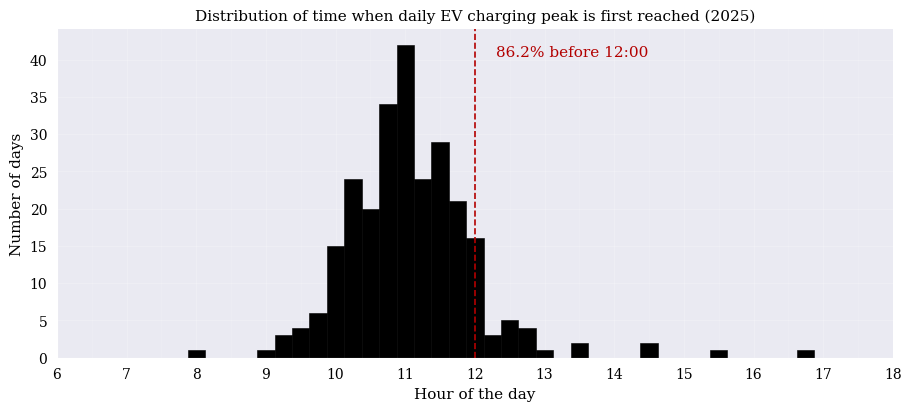

In [15]:
# Distribution (15-min base) of the first time the daily EV max (actual) is reached

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- KU Leuven thesis plotting style (see STYLE_GUIDE_PLOTS.md) ---
THESIS_STYLE = {
    # Typography
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    # Clean axes
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    # Black / KU Leuven red palette
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.prop_cycle": mpl.cycler(color=["black", "#b30000"]),
    # Grid
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    # Lines / export
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
}
mpl.rcParams.update(THESIS_STYLE)

# Start from the 2025 EV data used in this notebook
try:
    df_ev_2025 = df_2025.copy()
except NameError:
    df_ev_2025 = pd.read_csv(DATA_2025_PATH)

# Parse timestamps consistently with the rest of the notebook
ts_utc = pd.to_datetime(df_ev_2025["timestamp"], utc=True, errors="coerce")
df_ev_2025["timestamp"] = ts_utc.dt.tz_convert("Europe/Brussels").dt.tz_localize(None)
df_ev_2025 = df_ev_2025.sort_values("timestamp").reset_index(drop=True)

# Ensure EV column is numeric (actual EV energy per 15 min)
df_ev_2025["ev"] = pd.to_numeric(df_ev_2025["ev"], errors="coerce").fillna(0.0)

# Add day and 15-min slot index within the day
df_ev_2025["date"] = df_ev_2025["timestamp"].dt.date
df_ev_2025["slot_index"] = (
    df_ev_2025["timestamp"].dt.hour * 4
    + df_ev_2025["timestamp"].dt.minute // 15
).astype(int)  # 0..95

# For each day: earliest 15-min slot where EV reaches the daily max
def first_max_slot(g: pd.DataFrame) -> int:
    max_val = g["ev"].max()
    return int(g.loc[g["ev"] == max_val, "slot_index"].min())

first_max_slots = (
    df_ev_2025.groupby("date", group_keys=False)[["ev", "slot_index"]]
    .apply(first_max_slot)
)
first_max_slots.name = "slot_first_daily_ev_max"  # 0..95

# Convert slots back to time-of-day for readability (15-min base)
first_max_times_hours = first_max_slots * 0.25  # hours after midnight in {0.00, 0.25, ..., 23.75}

# Days where the daily EV max occurs at hour 0.00 are days with no EV activity
# (the first slot already equals the daily maximum of 0). Drop them so the
# distribution reflects only days with actual EV charging.
mask_active = first_max_times_hours > 0.0
first_max_times_hours_active = first_max_times_hours[mask_active]

n_total = int(len(first_max_times_hours))
n_active = int(mask_active.sum())
n_before_noon = int((first_max_times_hours_active < 12.0).sum())
pct_before_noon = 100.0 * n_before_noon / n_active if n_active > 0 else float("nan")

print("Summary statistics of the 15-min slot where the daily EV max is first reached:")
display(first_max_slots[mask_active].describe().to_frame().T)

print("\nSame in hours-of-day (slot*0.25h), excluding zero-EV days:")
display(first_max_times_hours_active.describe().to_frame().T)

print(
    f"\nDays with EV activity: {n_active} / {n_total} "
    f"({100.0 * n_active / n_total:.1f}% of the year)"
)
print(
    f"Daily EV max reached before 12:00: {n_before_noon} / {n_active} "
    f"({pct_before_noon:.1f}% of active days)"
)

# Histogram with hour-of-day on x-axis (15-min resolution)
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
bins = np.arange(0.125, 24.125 + 1e-9, 0.25)  # centers bins at 0.25, 0.50, ..., 23.75
ax.hist(
    first_max_times_hours_active.values,
    bins=bins,
    color="black",
    edgecolor="black",
    linewidth=0.4,
)

# Highlight the "before 12:00" region with the secondary KU Leuven red.
ax.axvline(12.0, color="#b30000", linewidth=1.2, linestyle="--")
ax.text(
    12.0 + 0.3,
    ax.get_ylim()[1] * 0.95,
    f"{pct_before_noon:.1f}% before 12:00",
    color="#b30000",
    ha="left",
    va="top",
)

ax.set_title("Distribution of time when daily EV charging peak is first reached (2025)")
ax.set_xlabel("Hour of the day")
ax.set_ylabel("Number of days")

# Hourly major ticks, half-hour minor ticks (recommended for dense time plots)
ax.set_xlim(6, 18)
ax.set_xticks(np.arange(6, 19, 1))
ax.set_xticks(np.arange(6.5, 18.5, 1.0), minor=True)

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="x", alpha=0.15)

plt.show()

## Part 4 – Chronos-2 daily EV energy (month-ahead, no foresight)

Uses the **daily EV energy** series from the yearly overview (`daily_ev_2024`, `daily_ev_2025`).

**Forecast protocol (no foresight):**
- At the **last calendar day of each month**, issue a **Chronos-2** forecast for **all days in the next month**.
- First issue: **2024-12-31** → daily EV energy for **January 2025** (then Feb from 2025-01-31, …).
- Context = measured daily EV energy on all dates **up to and including** the issue date.

**Quantiles:** only **p95** and **p99** (Chronos-2 also supports  
`0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9`).

Outputs: 2025 forecast vs actual plot (p95/p99), and a monthly table with **max** and **P95/P99** statistics.

Loading Chronos-2 (amazon/chronos-2) on cpu ...
Available quantiles: [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]
Using: [0.95, 0.99]
Issued 2024-12-31 → 2025-01 (31 days, context=239 days)
Issued 2025-01-31 → 2025-02 (28 days, context=270 days)
Issued 2025-02-28 → 2025-03 (31 days, context=298 days)
Issued 2025-03-31 → 2025-04 (30 days, context=329 days)
Issued 2025-04-30 → 2025-05 (31 days, context=359 days)
Issued 2025-05-31 → 2025-06 (30 days, context=390 days)
Issued 2025-06-30 → 2025-07 (31 days, context=420 days)
Issued 2025-07-31 → 2025-08 (31 days, context=451 days)
Issued 2025-08-31 → 2025-09 (30 days, context=482 days)
Issued 2025-09-30 → 2025-10 (31 days, context=512 days)
Issued 2025-10-31 → 2025-11 (30 days, context=512 days)
Issued 2025-11-30 → 2025-12 (31 days, context=512 days)


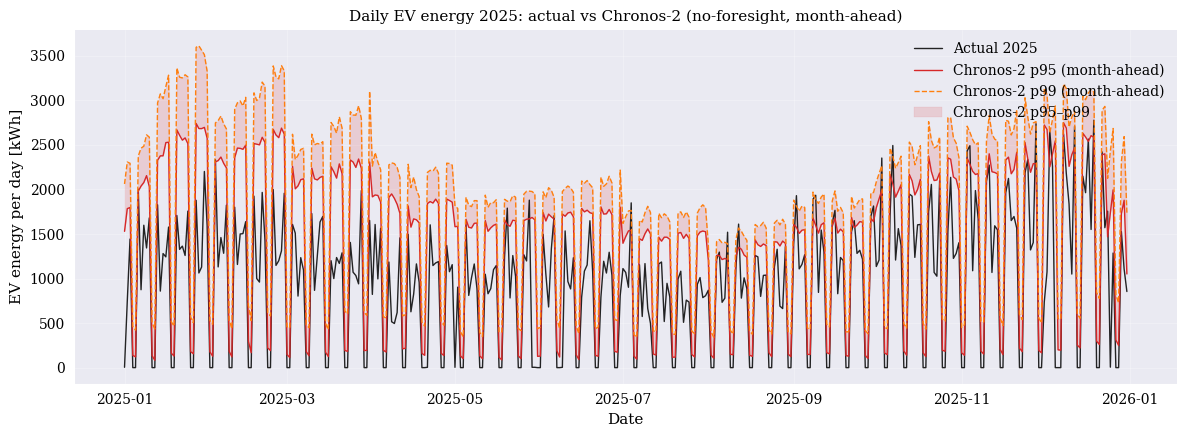

Exported 12 rows to C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\output\forecast\forecast_ev_monthly_p99_max_chronos2.csv
Exported 365 rows to C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\output\forecast\forecast_ev_daily_p99_chronos2.csv
Monthly daily EV energy – Chronos-2 (kWh/day):


,month,actual max,p95 max,p99 max,p95 error,p99 error
0,2025-01,2202.2,2741.3,3613.0,539.0,1410.7
1,2025-02,2334.1,2689.0,3390.9,355.0,1056.8
2,2025-03,1987.6,2342.1,3103.4,354.5,1115.8
3,2025-04,1607.1,1950.2,2415.1,343.2,808.1
4,2025-05,1880.3,1685.9,1981.3,-194.5,101.0
5,2025-06,1706.2,1804.1,2218.1,97.9,511.8
6,2025-07,1849.7,1557.1,1827.9,-292.6,-21.8
7,2025-08,1611.2,1434.5,1666.0,-176.7,54.8
8,2025-09,1934.9,1686.9,1984.3,-248.0,49.4
9,2025-10,2493.9,2374.7,2804.4,-119.2,310.5


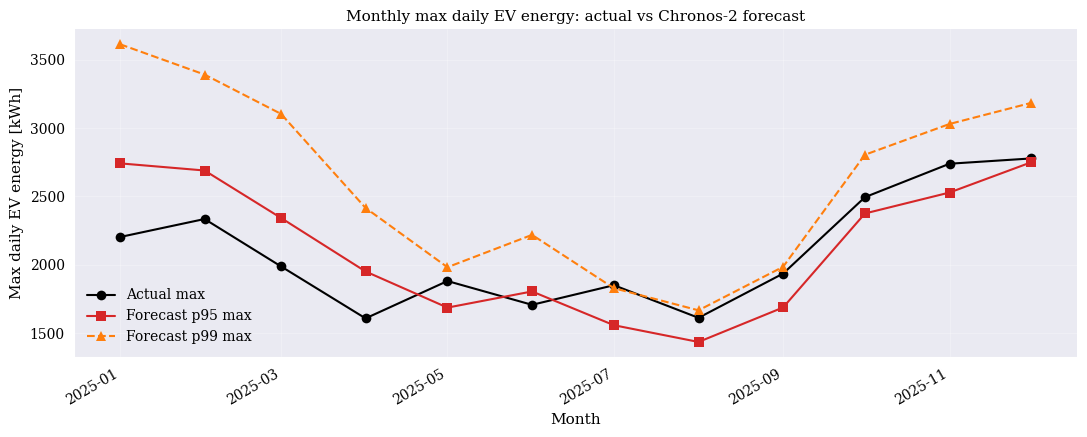

In [16]:
# Part 4 – Chronos-2 monthly roll-forward on daily EV energy (kWh/day)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from chronos import Chronos2Pipeline

# --- Daily series from Part 1 yearly overview ---
_daily_24 = daily_ev_2024.copy()
_daily_24["date"] = pd.to_datetime(_daily_24["date"])
_daily_25 = daily_ev_2025.copy()
_daily_25["date"] = pd.to_datetime(_daily_25["date"])

daily_ev_all = (
    pd.concat(
        [
            _daily_24.rename(columns={"ev_daily_kwh": "ev_daily_kwh"}),
            _daily_25[["date", "ev_daily_kwh"]],
        ],
        ignore_index=True,
    )
    .drop_duplicates(subset=["date"], keep="last")
    .sort_values("date")
    .reset_index(drop=True)
)

# Optional: drop pre-EV days in 2024 (same go-live logic as Part 1)
if "ev_start_date_2024" in globals():
    daily_ev_all = daily_ev_all[
        daily_ev_all["date"] >= pd.Timestamp(ev_start_date_2024)
    ].reset_index(drop=True)

y_by_date = daily_ev_all.set_index("date")["ev_daily_kwh"].astype(float)

# --- Chronos-2 config ---
CHRONOS2_MODEL = "amazon/chronos-2"
CONTEXT_MAX_DAYS = 512
QUANTILE_LEVELS = [0.95, 0.99]

_device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading Chronos-2 ({CHRONOS2_MODEL}) on {_device} ...")
chronos2_daily = Chronos2Pipeline.from_pretrained(CHRONOS2_MODEL, device_map=_device)
print("Available quantiles:", chronos2_daily.quantiles)
print("Using:", QUANTILE_LEVELS)

# Monthly forecast origins: last day of month M-1 → all days in month M (2025)
_issue_dates = [
    pd.Timestamp("2024-12-31"),
    *[pd.Timestamp(f"2025-{m:02d}-01") + pd.offsets.MonthEnd(0) for m in range(1, 12)],
]

_forecast_rows = []
for issue_date in _issue_dates:
    target_month = (issue_date + pd.Timedelta(days=1)).to_period("M")
    month_days = pd.date_range(
        target_month.start_time,
        target_month.end_time,
        freq="D",
    )
    hist = y_by_date.loc[:issue_date]
    if hist.empty:
        continue
    ctx = hist.iloc[-CONTEXT_MAX_DAYS:].to_numpy(dtype=np.float32)
    ctx = np.nan_to_num(ctx, nan=0.0)
    if len(ctx) < 7:
        ctx = np.pad(ctx, (7 - len(ctx), 0), mode="edge")

    ctx_t = torch.tensor(ctx, dtype=torch.float32).view(1, 1, -1)
    horizon = len(month_days)

    q_out, _mean = chronos2_daily.predict_quantiles(
        inputs=ctx_t,
        prediction_length=horizon,
        quantile_levels=QUANTILE_LEVELS,
        limit_prediction_length=False,
    )
    q_np = q_out[0].detach().cpu().numpy()[0]  # (horizon, 2) for p95, p99

    for i, d in enumerate(month_days):
        _forecast_rows.append(
            {
                "date": d.normalize(),
                "issue_date": issue_date,
                "target_month": str(target_month),
                "ev_daily_forecast_p95": float(np.clip(q_np[i, 0], 0.0, None)),
                "ev_daily_forecast_p99": float(np.clip(q_np[i, 1], 0.0, None)),
                "ev_daily_actual": float(y_by_date.get(d.normalize(), np.nan)),
            }
        )

    print(
        f"Issued {issue_date.date()} → {target_month} "
        f"({horizon} days, context={len(ctx)} days)"
    )

daily_ev_forecast_2025 = pd.DataFrame(_forecast_rows)
daily_ev_forecast_2025["date"] = pd.to_datetime(daily_ev_forecast_2025["date"])

# --- Plot: 2025 forecast vs actual (daily kWh) ---
_plot = daily_ev_forecast_2025.dropna(subset=["ev_daily_actual"]).copy()
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(
    _plot["date"],
    _plot["ev_daily_actual"],
    label="Actual 2025",
    color="black",
    lw=1.0,
    alpha=0.85,
)
ax.plot(
    _plot["date"],
    _plot["ev_daily_forecast_p95"],
    label="Chronos-2 p95 (month-ahead)",
    color="tab:red",
    lw=1.0,
)
ax.plot(
    _plot["date"],
    _plot["ev_daily_forecast_p99"],
    label="Chronos-2 p99 (month-ahead)",
    color="tab:orange",
    lw=1.0,
    linestyle="--",
)
ax.fill_between(
    _plot["date"],
    _plot["ev_daily_forecast_p95"],
    _plot["ev_daily_forecast_p99"],
    color="tab:red",
    alpha=0.15,
    label="Chronos-2 p95–p99",
)
ax.set_title("Daily EV energy 2025: actual vs Chronos-2 (no-foresight, month-ahead)")
ax.set_xlabel("Date")
ax.set_ylabel("EV energy per day [kWh]")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Monthly summary table: max daily energy & quantiles ---
def _monthly_daily_stats(g: pd.DataFrame, value_col: str, prefix: str) -> pd.Series:
    s = g[value_col].astype(float)
    s = s[np.isfinite(s)]
    if len(s) == 0:
        return pd.Series(dtype=float)
    return pd.Series(
        {
            f"{prefix}_max": s.max(),
            f"{prefix}_p99": s.quantile(0.99),
            f"{prefix}_p95": s.quantile(0.95),
            f"{prefix}_mean": s.mean(),
        }
    )


_monthly_stats = []
for month_key, g in daily_ev_forecast_2025.groupby("target_month"):
    row = {"month": month_key, "n_days": len(g)}
    row.update(_monthly_daily_stats(g, "ev_daily_actual", "actual").to_dict())
    row.update(_monthly_daily_stats(g, "ev_daily_forecast_p95", "forecast_p95").to_dict())
    row.update(_monthly_daily_stats(g, "ev_daily_forecast_p99", "forecast_p99").to_dict())
    m95 = np.isfinite(g["ev_daily_actual"]) & np.isfinite(g["ev_daily_forecast_p95"])
    m99 = np.isfinite(g["ev_daily_actual"]) & np.isfinite(g["ev_daily_forecast_p99"])
    if m95.any():
        row["mae_p95_kwh"] = float(
            np.mean(np.abs(g.loc[m95, "ev_daily_actual"] - g.loc[m95, "ev_daily_forecast_p95"]))
        )
        row["rmse_p95_kwh"] = float(
            np.sqrt(np.mean((g.loc[m95, "ev_daily_actual"] - g.loc[m95, "ev_daily_forecast_p95"]) ** 2))
        )
    else:
        row["mae_p95_kwh"] = np.nan
        row["rmse_p95_kwh"] = np.nan
    if m99.any():
        row["mae_p99_kwh"] = float(
            np.mean(np.abs(g.loc[m99, "ev_daily_actual"] - g.loc[m99, "ev_daily_forecast_p99"]))
        )
        row["rmse_p99_kwh"] = float(
            np.sqrt(np.mean((g.loc[m99, "ev_daily_actual"] - g.loc[m99, "ev_daily_forecast_p99"]) ** 2))
        )
    else:
        row["mae_p99_kwh"] = np.nan
        row["rmse_p99_kwh"] = np.nan
    _monthly_stats.append(row)

monthly_daily_ev_chronos2 = pd.DataFrame(_monthly_stats).set_index("month")

_summary = monthly_daily_ev_chronos2.reset_index()[
    ["month", "actual_max", "forecast_p95_max", "forecast_p99_max"]
].copy()
_summary["p95 error"] = _summary["forecast_p95_max"] - _summary["actual_max"]
_summary["p99 error"] = _summary["forecast_p99_max"] - _summary["actual_max"]
_summary = _summary[
    ["month", "actual_max", "forecast_p95_max", "forecast_p99_max", "p95 error", "p99 error"]
]
_summary.columns = [
    "month",
    "actual max",
    "p95 max",
    "p99 max",
    "p95 error",
    "p99 error",
]

# Export month + forecast p99 max (kWh/day) for downstream use
from pathlib import Path

_forecast_dir = Path("../output/forecast")
_forecast_dir.mkdir(parents=True, exist_ok=True)
_p99_export = _summary[["month", "p99 max"]].copy()
_p99_export.columns = ["month", "p99_max_kwh"]
P99_MAX_MONTHLY_PATH = _forecast_dir / "forecast_ev_monthly_p99_max_chronos2.csv"
_p99_export.to_csv(P99_MAX_MONTHLY_PATH, index=False)
print(f"Exported {len(_p99_export)} rows to {P99_MAX_MONTHLY_PATH.resolve()}")

P99_DAILY_PATH = _forecast_dir / "forecast_ev_daily_p99_chronos2.csv"
daily_ev_forecast_2025[["date", "ev_daily_forecast_p99"]].to_csv(
    P99_DAILY_PATH, index=False
)
print(f"Exported {len(daily_ev_forecast_2025)} rows to {P99_DAILY_PATH.resolve()}")

print("Monthly daily EV energy – Chronos-2 (kWh/day):")
display(_summary.round(1))

# --- Plot: monthly max daily EV energy (actual vs forecast p95/p99) ---
_month_x = pd.PeriodIndex(_summary["month"], freq="M").to_timestamp()
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(_month_x, _summary["actual max"], marker="o", label="Actual max", color="black", lw=1.5)
ax.plot(_month_x, _summary["p95 max"], marker="s", label="Forecast p95 max", color="tab:red", lw=1.5)
ax.plot(_month_x, _summary["p99 max"], marker="^", label="Forecast p99 max", color="tab:orange", lw=1.5, linestyle="--")
ax.set_title("Monthly max daily EV energy: actual vs Chronos-2 forecast")
ax.set_xlabel("Month")
ax.set_ylabel("Max daily EV energy [kWh]")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()